# 11. Support vector machines and kernel methods

Logistic regression (notebook 7) draws a line between two classes by maximising a
likelihood. Support vector machines (SVMs) draw a line too — but they choose it by a purely
geometric criterion: **put the boundary as far away from both classes as possible**. This
*maximum-margin* principle turns out to be a form of regularisation, it leads to a loss
function (the hinge loss) that we can minimise with the same gradient machinery as before,
and — through the *kernel trick* — it extends to boundaries that are not lines at all,
without ever computing the curved features explicitly.

Kernel methods were the state of the art in machine learning for roughly a decade (about
1995–2006) and remain the right tool for small-to-medium datasets with rich, non-linear
structure. More importantly, the ideas — margins, convex surrogate losses, the kernel
trick, Gaussian processes — appear everywhere else in the course: in regularisation
(notebook 6), in model selection (notebook 12, where Gaussian processes drive Bayesian
optimisation), in dimensionality reduction (notebook 14, kernel PCA) and even in
transformers (attention is a kernel-weighted average).

**Prerequisites:** notebooks 5 (evaluation), 6 (regularisation) and 7 (logistic
regression); vectors, dot products and gradients from notebook 2.

## Learning objectives

After working through this notebook you will be able to

- explain the maximum-margin principle, derive the hard-margin optimisation problem and identify the support vectors;
- write the soft-margin SVM as *regularised hinge-loss minimisation*, relate $C$ to the regularisation strength $\lambda$, and compare the hinge and logistic losses;
- implement a linear SVM with sub-gradient descent (Pegasos) and verify it against `LinearSVC` / `SVC`;
- state the dual problem, explain why only dot products appear, and use the kernel trick with polynomial and RBF kernels;
- read a $\gamma$/$C$ grid of decision boundaries and tune both parameters by cross-validation;
- apply the practical rules: scale the features, handle class imbalance, obtain probabilities, and switch to `LinearSVC` or kernel approximations (`Nystroem`, `RBFSampler`) when $n$ is large;
- use support vector regression, kernel ridge regression and Gaussian-process regression on the same problem and explain how they differ;
- state the strengths and weaknesses of each of the three models, and *show* three of the failures: the $O(n^2)$ scaling wall, memorisation at large $\gamma$, and the collapse on unscaled features;
- tune an SVM with the standard recipe — scale, then a log grid over $C$ and $\gamma$, then the kernel, `coef0`, `class_weight` or `epsilon` — and know what to do when the optimum sits at the edge of the grid or the curve is flat;
- decide when an SVM is (and is not) the right model.

## Setup

In [1]:
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from course_utils import set_style, PALETTE, plot_decision_boundary

RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)
set_style()

## 1. Maximum-margin classification

### 1.1 Which separating line?

Take two classes that can be separated by a straight line. There are infinitely many such
lines. The classical **perceptron** algorithm returns *any* of them — whichever it
stumbles upon first, depending on the order in which it visits the data.
Yet intuitively some lines are better than others: a line that grazes a training point is
fragile, because a slightly different sample of the same class would fall on the wrong
side. The most robust choice is the line that stays **as far as possible from the closest
points of both classes**. The distance from the boundary to the closest point is called
the **margin**, and the SVM is the classifier that maximises it.

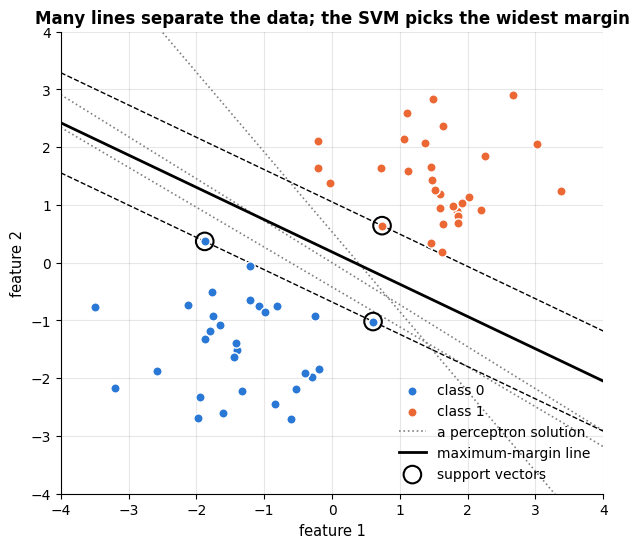

margin width 2/||w|| = 1.513;  support vectors: 3 of 60 points


In [2]:
from sklearn.datasets import make_blobs
from sklearn.linear_model import Perceptron
from sklearn.svm import SVC

X_sep, y_sep = make_blobs(n_samples=60, centers=[[-1.5, -1.5], [1.5, 1.5]], cluster_std=0.8, random_state=6)

# a hard-margin SVM: a huge C forbids any margin violation (section 2 explains C)
svm_hard = SVC(kernel="linear", C=1e6).fit(X_sep, y_sep)
w, b = svm_hard.coef_.ravel(), svm_hard.intercept_[0]

x_line = np.linspace(-4, 4, 50)
fig, ax = plt.subplots(figsize=(7, 6))
for i, c in enumerate([0, 1]):
    ax.scatter(*X_sep[y_sep == c].T, color=PALETTE[i], edgecolor="white", s=45, label=f"class {c}", zorder=3)
for s in [1, 3, 4]:                                   # three perceptrons, three different separating lines
    p = Perceptron(random_state=s).fit(X_sep, y_sep)
    wp, bp = p.coef_.ravel(), p.intercept_[0]
    ax.plot(x_line, -(wp[0] * x_line + bp) / wp[1], color="gray", lw=1.2, ls=":",
            label="a perceptron solution" if s == 1 else None)
ax.plot(x_line, -(w[0] * x_line + b) / w[1], color="black", lw=2, label="maximum-margin line")
for level in (-1, 1):                                 # the margin boundaries w.x + b = ±1
    ax.plot(x_line, -(w[0] * x_line + b - level) / w[1], color="black", lw=1, ls="--")
ax.scatter(*svm_hard.support_vectors_.T, s=160, facecolors="none", edgecolors="black", linewidths=1.5,
           label="support vectors", zorder=4)
ax.set_xlim(-4, 4)
ax.set_ylim(-4, 4)
ax.set_xlabel("feature 1")
ax.set_ylabel("feature 2")
ax.set_title("Many lines separate the data; the SVM picks the widest margin")
ax.legend(loc="lower right")
plt.show()
print(f"margin width 2/||w|| = {2 / np.linalg.norm(w):.3f};  support vectors: {svm_hard.n_support_.sum()} of {len(X_sep)} points")

### 1.2 Margins, formally

A linear classifier predicts $\hat{y} = \operatorname{sign}\big(f(\mathbf{x})\big)$ with
$f(\mathbf{x}) = \mathbf{w}^\top\mathbf{x} + b$; the boundary is the hyperplane
$\{\mathbf{x} : f(\mathbf{x}) = 0\}$. Throughout this notebook the labels are coded as
$y_i \in \{-1, +1\}$, which makes the algebra clean: a point is classified correctly
exactly when $y_i f(\mathbf{x}_i) > 0$.

*How far is a point from the hyperplane?* The vector $\mathbf{w}$ is orthogonal to the
hyperplane (for any two points $\mathbf{x}, \mathbf{x}'$ on it,
$\mathbf{w}^\top(\mathbf{x} - \mathbf{x}') = 0$). Write $\mathbf{x}_0 = \mathbf{x}_p + r\,\mathbf{w}/\|\mathbf{w}\|$,
where $\mathbf{x}_p$ is the orthogonal projection of $\mathbf{x}_0$ onto the hyperplane and
$r$ is the signed distance. Then
$f(\mathbf{x}_0) = \mathbf{w}^\top\mathbf{x}_p + b + r\,\|\mathbf{w}\| = r\,\|\mathbf{w}\|$, so

$$
r \;=\; \frac{f(\mathbf{x}_0)}{\|\mathbf{w}\|} \;=\; \frac{\mathbf{w}^\top\mathbf{x}_0 + b}{\|\mathbf{w}\|}.
$$

This motivates two definitions for a training point $(\mathbf{x}_i, y_i)$:

- the **functional margin** $\hat{\gamma}_i = y_i\,(\mathbf{w}^\top\mathbf{x}_i + b)$ — positive iff the point is on the correct side, but it can be inflated at will by rescaling $(\mathbf{w}, b)$;
- the **geometric margin** $\gamma_i = \hat{\gamma}_i / \|\mathbf{w}\|$ — the actual signed distance, invariant under rescaling.

The margin of the whole training set is $\gamma = \min_i \gamma_i$, and the maximum-margin
classifier solves $\max_{\mathbf{w}, b} \min_i \gamma_i$. Because $(\mathbf{w}, b)$ can be
rescaled freely, we may *fix the scale* by demanding that the closest points have
functional margin exactly $1$: $\min_i y_i(\mathbf{w}^\top\mathbf{x}_i + b) = 1$. The
geometric margin is then $1/\|\mathbf{w}\|$, and maximising it is the same as minimising
$\|\mathbf{w}\|$ — or, for a differentiable objective, $\tfrac12\|\mathbf{w}\|^2$:

$$
\min_{\mathbf{w}, b}\ \tfrac{1}{2}\|\mathbf{w}\|^2
\qquad\text{subject to}\qquad
y_i\,(\mathbf{w}^\top\mathbf{x}_i + b) \;\ge\; 1 \quad (i = 1, \dots, n).
\qquad\text{(hard-margin SVM)}
$$

This is a convex quadratic programme with linear constraints: it has a unique solution
and no local minima. The two dashed lines in the figure are $f(\mathbf{x}) = \pm 1$; the
distance between them, the *margin width*, is $2/\|\mathbf{w}\|$.

### 1.3 Support vectors

At the solution, most constraints are *slack* — the points sit comfortably beyond the
margin. Only the points with $y_i f(\mathbf{x}_i) = 1$, lying exactly on the dashed lines,
are *active*; they are the **support vectors**. Moving or deleting any other point does
not change the solution at all, as we can verify:

In [3]:
sv = svm_hard.support_
svm_sv_only = SVC(kernel="linear", C=1e6).fit(X_sep[sv], y_sep[sv])
print("w, b fitted on all 60 points:      ", w.round(4), round(b, 4))
print(f"w, b fitted on the {len(sv)} support vectors:", svm_sv_only.coef_.ravel().round(4), svm_sv_only.intercept_[0].round(4))

w, b fitted on all 60 points:       [0.645  1.1536] -0.2155
w, b fitted on the 3 support vectors: [0.645  1.1532] -0.2155


This sparsity is the source of the name and one of the model's practical strengths: the
decision function is determined by a (usually small) subset of the data.

> **History.** The maximum-margin idea goes back to Vapnik and Chervonenkis's work on
> statistical learning theory in the 1960s–70s; the kernelised "optimal margin classifier"
> was presented by Boser, Guyon & Vapnik (1992), and the soft-margin "support-vector
> network" that made the method practical by Cortes & Vapnik (1995). The theory behind
> it — margins bound the generalisation error independently of the dimension of the
> feature space — is developed in Vapnik (1995).

## 2. Soft margins and the hinge loss

### 2.1 Slack variables and the parameter $C$

Real data are rarely separable, and even when they are, a single outlier can force a tiny
margin. Cortes & Vapnik (1995) relaxed the constraints with **slack variables**
$\xi_i \ge 0$ that measure by how much point $i$ violates the margin, and charged a price
$C$ per unit of slack:

$$
\min_{\mathbf{w}, b, \boldsymbol{\xi}}\ \tfrac{1}{2}\|\mathbf{w}\|^2 + C \sum_{i=1}^n \xi_i
\qquad\text{subject to}\qquad
y_i(\mathbf{w}^\top\mathbf{x}_i + b) \ge 1 - \xi_i,\quad \xi_i \ge 0 .
\qquad\text{(soft-margin SVM)}
$$

A point with $\xi_i = 0$ is beyond the margin, $0 < \xi_i < 1$ is inside the margin but
correctly classified, and $\xi_i > 1$ is misclassified. The hyper-parameter $C > 0$
balances the two goals:

- **large $C$**: violations are expensive → few violations, narrow margin, wiggly, high-variance boundary (in the limit $C \to \infty$, the hard-margin SVM);
- **small $C$**: violations are cheap → wide margin, many points inside it, smoother, high-bias boundary.

### 2.2 The SVM as regularised empirical risk minimisation

The slack variables can be eliminated. For fixed $(\mathbf{w}, b)$ the cheapest feasible
$\xi_i$ is $\xi_i = \max\big(0,\ 1 - y_i f(\mathbf{x}_i)\big)$. Substituting and dividing
by $nC$ gives an unconstrained problem in the familiar "loss + penalty" form of
notebooks 5 and 6:

$$
\min_{\mathbf{w}, b}\ \frac{1}{n}\sum_{i=1}^n \underbrace{\max\big(0,\ 1 - y_i(\mathbf{w}^\top\mathbf{x}_i + b)\big)}_{\text{hinge loss } \ell_{\text{hinge}}}
\;+\; \frac{\lambda}{2}\|\mathbf{w}\|^2,
\qquad \lambda = \frac{1}{nC}.
$$

> **Key idea.** A linear SVM is empirical risk minimisation with the **hinge loss** and an
> $L_2$ penalty — exactly ridge-regularised logistic regression with the logistic loss
> swapped for the hinge. The margin is not a separate concept: it *is* the regulariser.

The hinge loss is one of several convex **surrogates** for the 0–1 loss that we actually
care about but cannot optimise (it is piecewise constant, so its gradient is zero almost
everywhere). Plotting them as a function of the margin $m = y f(\mathbf{x})$ shows the
family resemblance and the differences:

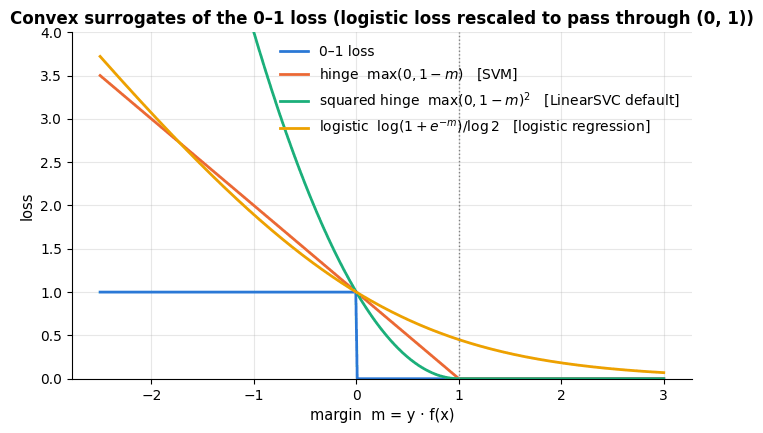

In [4]:
m = np.linspace(-2.5, 3, 400)
losses = {
    "0–1 loss": (m < 0).astype(float),
    "hinge  $\\max(0, 1-m)$   [SVM]": np.maximum(0, 1 - m),
    "squared hinge  $\\max(0, 1-m)^2$   [LinearSVC default]": np.maximum(0, 1 - m) ** 2,
    "logistic  $\\log(1+e^{-m}) / \\log 2$   [logistic regression]": np.log1p(np.exp(-m)) / np.log(2),
}
fig, ax = plt.subplots(figsize=(8, 4.5))
for name, val in losses.items():
    ax.plot(m, val, lw=2, label=name)
ax.axvline(1, color="gray", ls=":", lw=1)
ax.set_xlabel("margin  m = y · f(x)")
ax.set_ylabel("loss")
ax.set_ylim(0, 4)
ax.set_title("Convex surrogates of the 0–1 loss (logistic loss rescaled to pass through (0, 1))")
ax.legend()
plt.show()

- All surrogates are **upper bounds** on the 0–1 loss and **convex**, so minimising them is tractable, and a small surrogate loss guarantees few errors.
- The **hinge** loss is *exactly zero* for $m \ge 1$: points beyond the margin contribute nothing to the gradient, which is why the solution depends only on the support vectors. The **logistic** loss is never zero: every point keeps pulling on the boundary, so logistic regression has no support vectors and its solution depends on all the data.
- The hinge loss is not differentiable at $m = 1$ (a *kink*), which is why we need sub-gradients below; the squared hinge is smooth and is `LinearSVC`'s default (`loss="squared_hinge"`).
- Neither hinge loss yields probabilities; the logistic loss does (section 4).

### 2.3 Sub-gradient descent from scratch (Pegasos)

Because the hinge loss has a kink, we use a **sub-gradient**: any vector that lies below
the function like a tangent would. For the objective above, a sub-gradient with respect to
$\mathbf{w}$ is

$$
\mathbf{g}_{\mathbf{w}} \;=\; \lambda\mathbf{w} \;-\; \frac{1}{n}\sum_{i:\ y_i f(\mathbf{x}_i) < 1} y_i\,\mathbf{x}_i,
\qquad
g_b \;=\; -\frac{1}{n}\sum_{i:\ y_i f(\mathbf{x}_i) < 1} y_i ,
$$

i.e. only the *margin violators* ($y_i f(\mathbf{x}_i) < 1$) push on the parameters, each
in the direction that would increase its margin. **Pegasos** (Shalev-Shwartz et al., 2011)
is sub-gradient descent on this objective with the step size $\eta_t = 1/(\lambda t)$,
evaluated on a random mini-batch at each step, followed by an optional projection of
$\mathbf{w}$ onto the ball of radius $1/\sqrt{\lambda}$ (the optimum provably lies inside
it, and the projection tames the first, very large steps). Its convergence rate does not
depend on $n$ at all, which made it the standard trainer for linear SVMs on large data.
We implement the mini-batch version with the projection, keep the bias $b$ unregularised,
and record the full-data objective after every step so that we can watch it converge.

In [5]:
class HingeLinearSVM:
    """Linear SVM trained by mini-batch sub-gradient descent (Pegasos, Shalev-Shwartz et al. 2011).

    Minimises  J(w, b) = mean_i max(0, 1 - y_i (w.x_i + b)) + (lam / 2) ||w||^2   with y_i in {-1, +1}.
    """

    def __init__(self, lam=0.01, n_iter=1000, batch_size=None, random_state=RANDOM_STATE):
        self.lam, self.n_iter, self.batch_size, self.random_state = lam, n_iter, batch_size, random_state

    def objective(self, X, y, w=None, b=None):
        w = self.w if w is None else w
        b = self.b if b is None else b
        return np.maximum(0.0, 1.0 - y * (X @ w + b)).mean() + 0.5 * self.lam * w @ w

    def fit(self, X, y):
        rng = np.random.default_rng(self.random_state)
        n, d = X.shape
        k = n if self.batch_size is None else self.batch_size
        self.w, self.b, self.history = np.zeros(d), 0.0, []
        for t in range(1, self.n_iter + 1):
            idx = slice(None) if k == n else rng.choice(n, k, replace=False)
            Xb, yb = X[idx], y[idx]
            active = yb * (Xb @ self.w + self.b) < 1          # margin violators
            grad_w = self.lam * self.w - (yb[active] @ Xb[active]) / k
            grad_b = -yb[active].sum() / k
            eta = 1.0 / (self.lam * t)                         # Pegasos step size
            self.w -= eta * grad_w
            self.b -= eta * grad_b
            self.w *= min(1.0, 1.0 / (np.sqrt(self.lam) * np.linalg.norm(self.w) + 1e-12))   # projection
            self.history.append(self.objective(X, y))
        return self

    def decision_function(self, X):
        return X @ self.w + self.b

    def predict(self, X):
        return np.where(self.decision_function(X) >= 0, 1, -1)

We train it on the breast cancer data (notebook 5), standardised — for SVMs scaling is
not optional, as section 4 will show — with labels recoded to $\pm 1$.

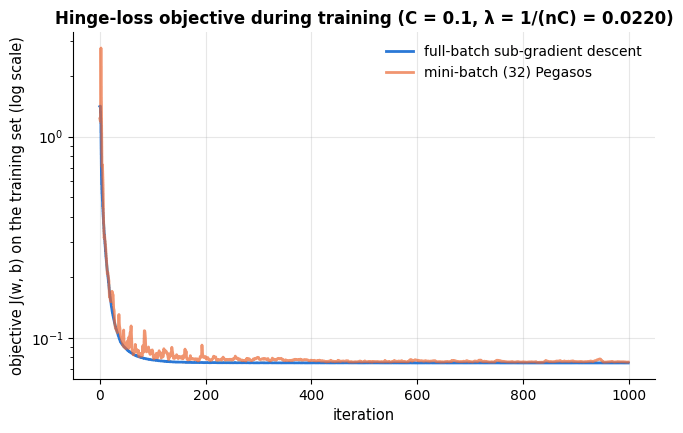

test accuracy  full-batch: 0.982   mini-batch: 0.982


In [6]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

cancer = load_breast_cancer()
X_c, y_c = cancer.data, np.where(cancer.target == 1, 1, -1)       # +1 = benign, -1 = malignant
X_c_train, X_c_test, y_c_train, y_c_test = train_test_split(X_c, y_c, test_size=0.2, stratify=y_c, random_state=RANDOM_STATE)
scaler = StandardScaler().fit(X_c_train)
X_c_train_s, X_c_test_s = scaler.transform(X_c_train), scaler.transform(X_c_test)

C = 0.1
lam = 1.0 / (len(X_c_train_s) * C)
ours_batch = HingeLinearSVM(lam=lam, n_iter=1000).fit(X_c_train_s, y_c_train)
ours_mini = HingeLinearSVM(lam=lam, n_iter=1000, batch_size=32).fit(X_c_train_s, y_c_train)

fig, ax = plt.subplots()
ax.plot(ours_batch.history, label="full-batch sub-gradient descent")
ax.plot(ours_mini.history, alpha=0.7, label="mini-batch (32) Pegasos")
ax.set_yscale("log")
ax.set_xlabel("iteration")
ax.set_ylabel("objective J(w, b) on the training set (log scale)")
ax.set_title(f"Hinge-loss objective during training (C = {C}, λ = 1/(nC) = {lam:.4f})")
ax.legend()
plt.show()
print(f"test accuracy  full-batch: {np.mean(ours_batch.predict(X_c_test_s) == y_c_test):.3f}   "
      f"mini-batch: {np.mean(ours_mini.predict(X_c_test_s) == y_c_test):.3f}")

### 2.4 Checking against scikit-learn

scikit-learn offers two linear SVM trainers. `SVC(kernel="linear")` solves the *dual*
problem (section 3) with LIBSVM (Chang & Lin, 2011) and uses the objective above exactly
(bias unregularised). `LinearSVC` uses LIBLINEAR (Fan et al., 2008), scales to much larger
$n$, defaults to the *squared* hinge loss and — a small but real difference — regularises
the bias as well (it appends a constant feature `intercept_scaling`). Both take $C$, not
$\lambda$. The decisive check is not the accuracy (many different weight vectors give the
same accuracy) but the **value of the objective**: our optimiser should reach the same
minimum as LIBSVM's exact solver.

In [7]:
from sklearn.svm import LinearSVC

svc_lin = SVC(kernel="linear", C=C).fit(X_c_train_s, y_c_train)
lsvc = LinearSVC(C=C, loss="hinge", max_iter=50_000).fit(X_c_train_s, y_c_train)   # hinge, not the squared-hinge default

def cosine(u, v):
    return u @ v / (np.linalg.norm(u) * np.linalg.norm(v))

rows = []
for name, w_, b_, acc in [
    ("ours (Pegasos, full batch)", ours_batch.w, ours_batch.b, np.mean(ours_batch.predict(X_c_test_s) == y_c_test)),
    ("ours (Pegasos, mini-batch)", ours_mini.w, ours_mini.b, np.mean(ours_mini.predict(X_c_test_s) == y_c_test)),
    ("SVC(kernel='linear')", svc_lin.coef_.ravel(), svc_lin.intercept_[0], svc_lin.score(X_c_test_s, y_c_test)),
    ("LinearSVC(loss='hinge')", lsvc.coef_.ravel(), lsvc.intercept_[0], lsvc.score(X_c_test_s, y_c_test)),
]:
    rows.append({"model": name, "objective J(w,b)": ours_batch.objective(X_c_train_s, y_c_train, w_, b_),
                 "||w||": np.linalg.norm(w_), "cosine(w, w_SVC)": cosine(w_, svc_lin.coef_.ravel()), "test accuracy": acc})
pd.DataFrame(rows).set_index("model").round(4)

,"objective J(w,b)",||w||,"cosine(w, w_SVC)",test accuracy
model,,,,
"ours (Pegasos, full batch)",0.0751,1.3850,0.9998,0.9825
"ours (Pegasos, mini-batch)",0.0758,1.3878,0.9983,0.9825
SVC(kernel='linear'),0.0750,1.3852,1.0000,0.9825
LinearSVC(loss='hinge'),0.0751,1.3912,0.9993,0.9825


The from-scratch optimiser reaches the same objective value as LIBSVM to four decimals,
with a weight vector pointing in the same direction (cosine ≈ 1). `LinearSVC` lands
slightly higher on *our* objective because it optimises a slightly different one (the
penalised bias) — a reminder that "the SVM" in different libraries can differ in details
that matter when you compare coefficients.

### 2.5 The effect of $C$

On overlapping classes, $C$ trades margin width against training errors. The dashed lines
are the margin ($f = \pm 1$), the circled points are the support vectors — everything on or
inside the margin, plus the misclassified points.

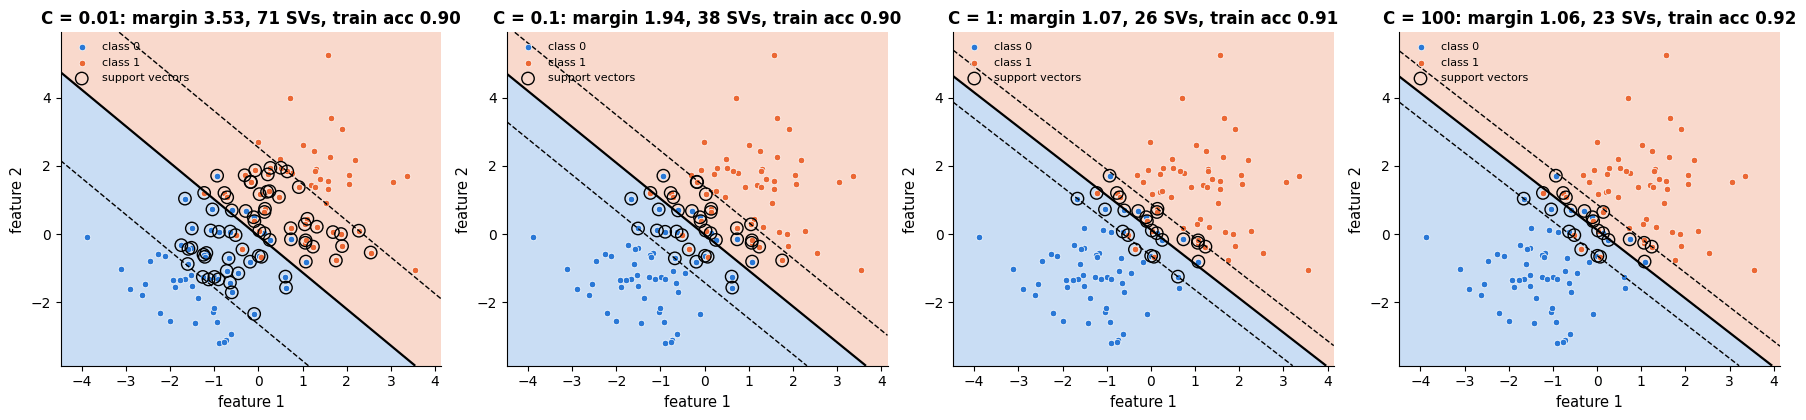

In [8]:
def plot_svm_margin(model, X, y, ax, title):
    """Decision regions, the margin lines f(x) = -1, 0, +1 and the support vectors of a fitted 2-D SVC."""
    plot_decision_boundary(model, X, y, ax=ax, title=title)
    xx, yy = np.meshgrid(np.linspace(*ax.get_xlim(), 200), np.linspace(*ax.get_ylim(), 200))
    zz = model.decision_function(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contour(xx, yy, zz, levels=[-1, 0, 1], colors="black", linestyles=["--", "-", "--"], linewidths=[1, 1.6, 1])
    ax.scatter(*model.support_vectors_.T, s=80, facecolors="none", edgecolors="black", linewidths=1, label="support vectors")
    ax.legend(loc="upper left", fontsize=8)

X_ov, y_ov = make_blobs(n_samples=120, centers=[[-1, -1], [1, 1]], cluster_std=1.1, random_state=RANDOM_STATE)
fig, axes = plt.subplots(1, 4, figsize=(18, 4.3))
for ax, C_ in zip(axes, [0.01, 0.1, 1, 100]):
    m_ = SVC(kernel="linear", C=C_).fit(X_ov, y_ov)
    plot_svm_margin(m_, X_ov, y_ov, ax, title=f"C = {C_}: margin {2 / np.linalg.norm(m_.coef_):.2f}, "
                                              f"{m_.n_support_.sum()} SVs, train acc {m_.score(X_ov, y_ov):.2f}")
plt.tight_layout()
plt.show()

Small $C$ gives a wide margin that most points fall inside (many support vectors, a
smooth, stable boundary); large $C$ narrows the margin until only a handful of points
determine it. In practice $C$ is chosen by cross-validation on a logarithmic grid
(section 3.4 and notebook 12), and the choice interacts with the kernel parameters.

## 3. The dual problem and the kernel trick

### 3.1 The dual

Constrained convex problems have a *dual* formulation obtained through Lagrange
multipliers (Boyd & Vandenberghe, 2004, ch. 5). For the soft-margin SVM, introducing one
multiplier $\alpha_i \ge 0$ per margin constraint and eliminating $\mathbf{w}$, $b$ and
$\boldsymbol{\xi}$ gives (we state it; the derivation is in Bishop, 2006, §7.1 or
Hastie et al., 2009, §12.2)

$$
\max_{\boldsymbol{\alpha}}\ \sum_{i=1}^n \alpha_i \;-\; \frac{1}{2}\sum_{i=1}^n\sum_{j=1}^n \alpha_i\alpha_j\, y_i y_j\, \mathbf{x}_i^\top\mathbf{x}_j
\qquad\text{subject to}\qquad 0 \le \alpha_i \le C,\quad \sum_{i=1}^n \alpha_i y_i = 0 ,
$$

with the primal solution recovered as

$$
\mathbf{w} = \sum_{i=1}^n \alpha_i y_i\, \mathbf{x}_i,
\qquad
f(\mathbf{x}) = \sum_{i=1}^n \alpha_i y_i\, \mathbf{x}_i^\top\mathbf{x} + b .
$$

Two things are remarkable about this form. First, the optimality (Karush–Kuhn–Tucker)
conditions say that $\alpha_i = 0$ for every point beyond the margin, $0 < \alpha_i < C$
for points exactly on it, and $\alpha_i = C$ for margin violators: **the $\alpha_i$ are
non-zero only for support vectors**, so the weight vector is a sparse combination of
training points. Second, the data enter the dual *only through dot products*
$\mathbf{x}_i^\top\mathbf{x}_j$ — never as individual coordinates. This is the door to
kernels. scikit-learn exposes the products $\alpha_i y_i$ as `dual_coef_`, which lets us
check the first claim numerically:

In [9]:
alpha_y = svc_lin.dual_coef_.ravel()                    # alpha_i * y_i for the support vectors only
w_from_dual = alpha_y @ svc_lin.support_vectors_        # w = sum_i alpha_i y_i x_i
print(f"support vectors: {len(alpha_y)} of {len(X_c_train_s)} training points")
print(f"max |w_from_dual - coef_| = {np.abs(w_from_dual - svc_lin.coef_.ravel()).max():.2e}")
print(f"alpha_i in [0, C]: min = {np.abs(alpha_y).min():.4f}, max = {np.abs(alpha_y).max():.4f} (C = {C});"
      f" {np.isclose(np.abs(alpha_y), C).sum()} points at the bound alpha_i = C (margin violators)")

support vectors: 51 of 455 training points
max |w_from_dual - coef_| = 0.00e+00
alpha_i in [0, C]: min = 0.0134, max = 0.1000 (C = 0.1); 36 points at the bound alpha_i = C (margin violators)


### 3.2 The kernel trick

Suppose we want a *non-linear* boundary. The classical recipe (notebooks 5 and 6) is to
map the inputs to a richer feature space, $\mathbf{x} \mapsto \boldsymbol{\phi}(\mathbf{x})$
(all monomials up to degree $p$, say), and fit a linear model there. In the dual, the
feature map appears only inside dot products
$\boldsymbol{\phi}(\mathbf{x}_i)^\top\boldsymbol{\phi}(\mathbf{x}_j)$. If we have a function
$k$ — a **kernel** — that computes this dot product *directly*,

$$
k(\mathbf{x}, \mathbf{z}) \;=\; \boldsymbol{\phi}(\mathbf{x})^\top \boldsymbol{\phi}(\mathbf{z}),
$$

then we can train and predict without ever forming $\boldsymbol{\phi}(\mathbf{x})$: replace
every $\mathbf{x}_i^\top\mathbf{x}_j$ by $k(\mathbf{x}_i, \mathbf{x}_j)$ in the dual and every
$\mathbf{x}_i^\top\mathbf{x}$ by $k(\mathbf{x}_i, \mathbf{x})$ in the decision function,

$$
f(\mathbf{x}) \;=\; \sum_{i \in \text{SV}} \alpha_i y_i\, k(\mathbf{x}_i, \mathbf{x}) + b .
$$

This substitution is the **kernel trick** (Aizerman, Braverman & Rozonoer, 1964; Boser
et al., 1992). Its power is that $\boldsymbol{\phi}$ can be enormous — or infinite — while
$k$ stays cheap. The $n \times n$ matrix $\mathbf{K}_{ij} = k(\mathbf{x}_i, \mathbf{x}_j)$
is the **Gram** or **kernel matrix**. Which functions $k$ are legitimate, i.e. correspond
to *some* feature map? **Mercer's condition**: $k$ must be symmetric and every kernel
matrix it produces must be positive semi-definite. The standard kernels in `SVC` are

| `kernel=` | $k(\mathbf{x}, \mathbf{z})$ | parameters | feature space |
|---|---|---|---|
| `"linear"` | $\mathbf{x}^\top\mathbf{z}$ | — | the inputs themselves |
| `"poly"` | $(\gamma\,\mathbf{x}^\top\mathbf{z} + r)^p$ | `gamma`, `coef0` $= r$, `degree` $= p$ | all monomials of degree $\le p$ |
| `"rbf"` (Gaussian) | $\exp(-\gamma\,\|\mathbf{x} - \mathbf{z}\|^2)$ | `gamma` $= 1/(2\sigma^2)$ | infinite-dimensional |
| `"sigmoid"` | $\tanh(\gamma\,\mathbf{x}^\top\mathbf{z} + r)$ | `gamma`, `coef0` | not a Mercer kernel for all parameters; rarely useful |

Sums and products of kernels are kernels, which is how custom kernels are built for
strings, graphs or images (Schölkopf & Smola, 2002).

### 3.3 Making the feature map explicit

For the polynomial kernel we can write $\boldsymbol{\phi}$ down and check the identity.
In two dimensions with $p = 2$, $\gamma = 1$, $r = 1$:

$$
(\mathbf{x}^\top\mathbf{z} + 1)^2 = 1 + 2x_1z_1 + 2x_2z_2 + x_1^2z_1^2 + x_2^2z_2^2 + 2x_1x_2z_1z_2
= \boldsymbol{\phi}(\mathbf{x})^\top\boldsymbol{\phi}(\mathbf{z}),
$$

$$
\boldsymbol{\phi}(\mathbf{x}) = \big(1,\ \sqrt{2}\,x_1,\ \sqrt{2}\,x_2,\ x_1^2,\ x_2^2,\ \sqrt{2}\,x_1x_2\big)^\top .
$$

In [10]:
from sklearn.metrics.pairwise import polynomial_kernel, rbf_kernel
from sklearn.datasets import make_circles
from math import comb

def phi_poly2(X):
    """Explicit feature map of the kernel (x.z + 1)^2 in two dimensions."""
    x1, x2 = X[:, 0], X[:, 1]
    return np.column_stack([np.ones(len(X)), np.sqrt(2) * x1, np.sqrt(2) * x2, x1**2, x2**2, np.sqrt(2) * x1 * x2])

X_circ, y_circ = make_circles(n_samples=200, noise=0.08, factor=0.45, random_state=RANDOM_STATE)
K_kernel = polynomial_kernel(X_circ, degree=2, gamma=1.0, coef0=1.0)     # (x.z + 1)^2, n x n
K_explicit = phi_poly2(X_circ) @ phi_poly2(X_circ).T                      # phi(x).phi(z)
print(f"max |K_kernel - K_explicit| = {np.abs(K_kernel - K_explicit).max():.2e}")

# a linear SVM on phi(x) and a kernel SVM on x must give the same decision function
svm_explicit = SVC(kernel="linear", C=1.0).fit(phi_poly2(X_circ), y_circ)
svm_kernel = SVC(kernel="poly", degree=2, gamma=1.0, coef0=1.0, C=1.0).fit(X_circ, y_circ)
diff = np.abs(svm_explicit.decision_function(phi_poly2(X_circ)) - svm_kernel.decision_function(X_circ)).max()
print(f"max |f_explicit(x) - f_kernel(x)| over the training points = {diff:.2e}")
print(f"features of the degree-p polynomial map in d dimensions, C(d+p, p): "
      f"d=2,p=2 -> {comb(4, 2)};  d=64,p=3 -> {comb(67, 3):,};  d=784,p=3 -> {comb(787, 3):,}")

max |K_kernel - K_explicit| = 2.66e-15
max |f_explicit(x) - f_kernel(x)| over the training points = 1.51e-14
features of the degree-p polynomial map in d dimensions, C(d+p, p): d=2,p=2 -> 6;  d=64,p=3 -> 47,905;  d=784,p=3 -> 80,931,145


The kernel evaluates the dot product of 6-dimensional feature vectors with one 2-D dot
product and a square; for the 8 × 8 digit images of section 8 ($d = 64$) a cubic feature
map would have almost 48 000 coordinates and for 28 × 28 images 81 million — yet the
kernel still costs $O(d)$. For the **RBF kernel** no finite $\boldsymbol{\phi}$ exists at
all: expanding the exponential in one dimension,
$e^{-\gamma(x - z)^2} = e^{-\gamma x^2} e^{-\gamma z^2} \sum_{k=0}^{\infty} \frac{(2\gamma)^k}{k!} x^k z^k$,
which is a dot product of infinitely many monomial features. Intuitively, the RBF kernel is
a *similarity* that decays with distance: $k = 1$ for identical points, $\approx 0$ for
points further apart than a few $\sigma = 1/\sqrt{2\gamma}$. The decision function
$\sum_i \alpha_i y_i k(\mathbf{x}_i, \mathbf{x}) + b$ is then a sum of Gaussian bumps of
either sign centred on the support vectors — a weighted, soft nearest-neighbour vote
(notebook 8), with $\gamma$ setting the neighbourhood size.

In [11]:
gamma = 0.5
sq_dists = ((X_circ[:, None, :] - X_circ[None, :, :]) ** 2).sum(-1)     # ||x_i - x_j||^2 by broadcasting
K_rbf_hand = np.exp(-gamma * sq_dists)
print(f"max |K_hand - rbf_kernel| = {np.abs(K_rbf_hand - rbf_kernel(X_circ, gamma=gamma)).max():.1e}")
eigvals = np.linalg.eigvalsh(K_rbf_hand)
print(f"kernel matrix is symmetric: {np.allclose(K_rbf_hand, K_rbf_hand.T)};  "
      f"smallest eigenvalue = {eigvals.min():.2e} (>= 0 up to rounding: Mercer's condition holds)")

max |K_hand - rbf_kernel| = 3.3e-16
kernel matrix is symmetric: True;  smallest eigenvalue = -1.24e-14 (>= 0 up to rounding: Mercer's condition holds)


### 3.4 The roles of $\gamma$ and $C$

With the RBF kernel an SVM has two hyper-parameters: $C$ (margin violations) and $\gamma$
(kernel width). Their effect is best understood visually. We use the "two moons" data with
substantial noise, so that a perfect fit is not possible and overfitting is visible.

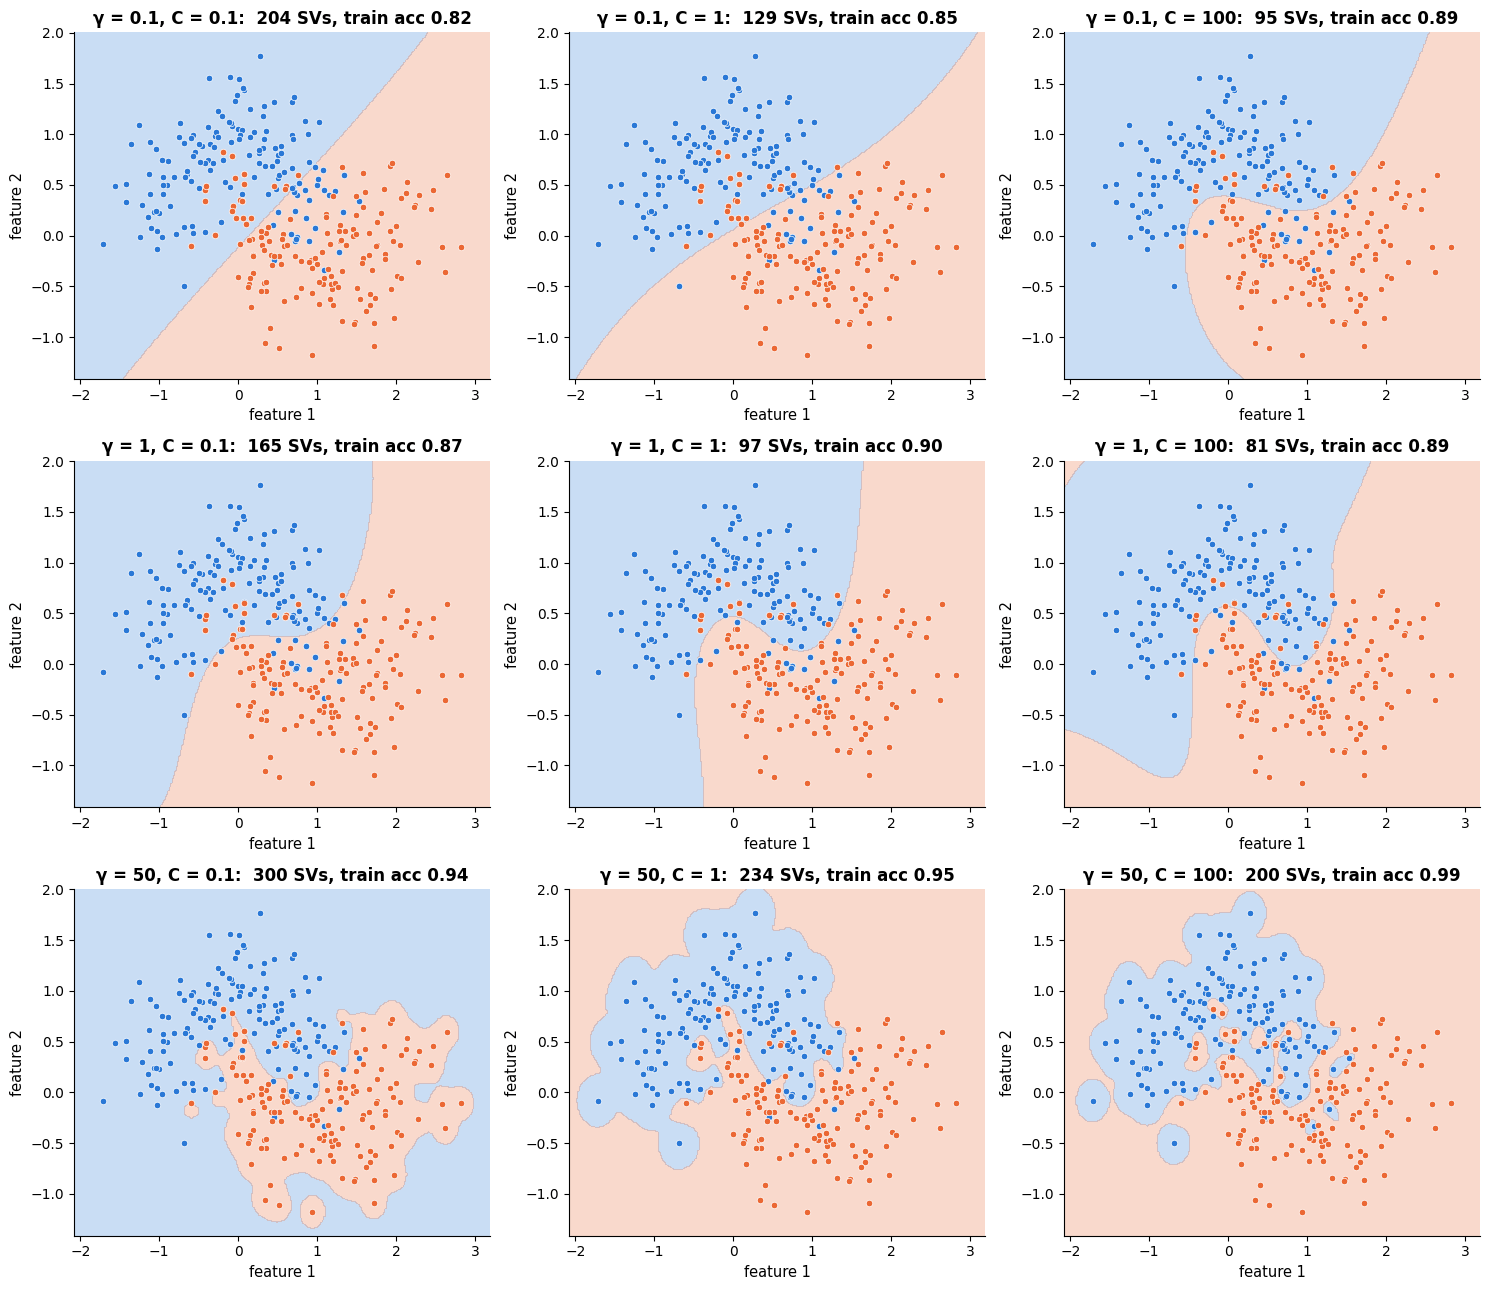

In [12]:
from sklearn.datasets import make_moons

X_moon, y_moon = make_moons(n_samples=300, noise=0.3, random_state=RANDOM_STATE)
gammas, Cs = [0.1, 1, 50], [0.1, 1, 100]
fig, axes = plt.subplots(len(gammas), len(Cs), figsize=(15, 13))
for i, g in enumerate(gammas):
    for j, C_ in enumerate(Cs):
        m_ = SVC(kernel="rbf", gamma=g, C=C_).fit(X_moon, y_moon)
        plot_decision_boundary(m_, X_moon, y_moon, ax=axes[i, j],
                               title=f"γ = {g}, C = {C_}:  {m_.n_support_.sum()} SVs, train acc {m_.score(X_moon, y_moon):.2f}")
        axes[i, j].get_legend().remove()
plt.tight_layout()
plt.show()

Read the grid row by row and column by column:

- **$\gamma$ sets the smoothness.** Small $\gamma$ (wide bumps, top row): every support vector influences a large region and the boundary is nearly linear — high bias. Large $\gamma$ (bottom row): each support vector only affects its immediate neighbourhood, and the boundary becomes a collection of islands around individual training points — high variance, memorisation.
- **$C$ sets the tolerance for violations.** Small $C$ (left column): smooth boundaries and many support vectors; large $C$ (right column): the model works hard to classify every training point, which with a large $\gamma$ is pure overfitting.
- The two interact: a larger $\gamma$ needs a smaller $C$ and vice versa, so the good configurations form a *diagonal ridge* in the $(\gamma, C)$ plane. A grid search over both on logarithmic scales, as recommended in the classic practical guide by Hsu, Chang & Lin (2003), is the standard procedure.

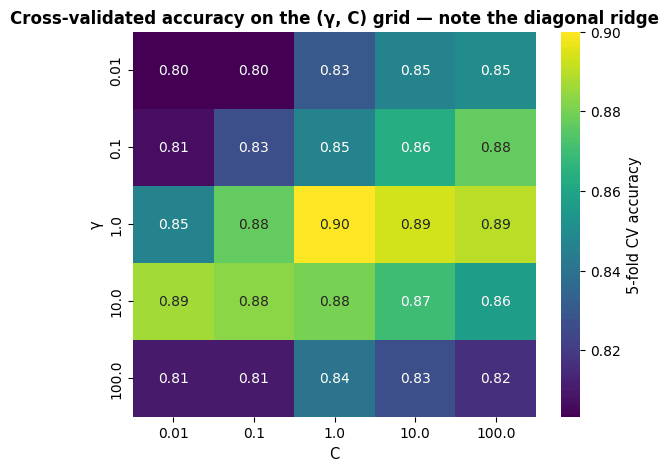

best: {'C': np.float64(1.0), 'gamma': np.float64(1.0)}, CV accuracy 0.900


In [13]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
param_grid = {"gamma": np.logspace(-2, 2, 5), "C": np.logspace(-2, 2, 5)}
grid_moon = GridSearchCV(SVC(kernel="rbf"), param_grid, cv=cv).fit(X_moon, y_moon)
scores = pd.DataFrame(grid_moon.cv_results_).pivot(index="param_gamma", columns="param_C", values="mean_test_score")

fig, ax = plt.subplots(figsize=(6.5, 5))
sns.heatmap(scores, annot=True, fmt=".2f", cmap="viridis", ax=ax, cbar_kws={"label": "5-fold CV accuracy"})
ax.grid(False)
ax.set_xlabel("C")
ax.set_ylabel("γ")
ax.set_title("Cross-validated accuracy on the (γ, C) grid — note the diagonal ridge")
plt.show()
print(f"best: {grid_moon.best_params_}, CV accuracy {grid_moon.best_score_:.3f}")

## 4. Practicalities

### 4.1 Scale your features

Both the margin and the RBF kernel are defined through Euclidean distances, so a feature
measured in thousands dominates one measured in tenths. The default
`gamma="scale"` ($=1/(d \cdot \operatorname{Var}(\mathbf{X}))$) compensates for the overall
scale of the data but not for differences *between* features. On the breast cancer data
the features range from ~0.05 (smoothness) to ~2 500 (area):

In [14]:
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import cross_val_score

for name, model in [("SVC(rbf) on raw features", SVC()),
                    ("SVC(rbf) after StandardScaler", make_pipeline(StandardScaler(), SVC()))]:
    acc = cross_val_score(model, X_c_train, y_c_train, cv=cv)
    print(f"{name:32s} CV accuracy = {acc.mean():.3f} ± {acc.std():.3f}")

SVC(rbf) on raw features         CV accuracy = 0.905 ± 0.034
SVC(rbf) after StandardScaler    CV accuracy = 0.969 ± 0.015


Scaling belongs *inside* the pipeline so that it is fitted on training folds only
(notebook 5, section 7). `StandardScaler` is the usual choice; `MinMaxScaler` to $[-1, 1]$
is what the LIBSVM guide recommends; for sparse text features (notebook 15) leave the
TF-IDF normalisation as it is.

### 4.2 Class imbalance, probabilities, multi-class

- **Imbalance.** `class_weight="balanced"` (or a dict) multiplies $C$ for each class by a
  weight inversely proportional to its frequency, so that misclassifying a rare positive
  costs more slack than misclassifying a common negative. Combine with the metrics of
  notebook 7 (PR-AUC, $F_1$) rather than accuracy.
- **Probabilities.** An SVM outputs a signed distance, not a probability.
  `SVC(probability=True)` fits **Platt scaling** (Platt, 1999) — a logistic regression
  $P(y = 1 \mid f) = \sigma(a f + c)$ on the decision values, using an internal 5-fold
  cross-validation so that the sigmoid is not fitted on the same points the SVM was
  trained on. It multiplies the training time by about five and the resulting
  `predict_proba` can even disagree with `predict` near the boundary; `CalibratedClassifierCV`
  (notebook 7) is the more general tool, and if calibrated probabilities are the goal,
  logistic regression may be the better model in the first place.
- **Multi-class.** `SVC` trains one binary SVM per *pair* of classes (one-vs-one, $K(K-1)/2$
  models, each on a small subset of the data) and lets them vote; `LinearSVC` trains
  one-vs-rest ($K$ models). `decision_function_shape="ovr"` (the default) aggregates the
  pairwise votes into a `(n, K)` array so that the API looks like other classifiers.

In [15]:
from sklearn.datasets import load_digits

digits = load_digits()
X_d_train, X_d_test, y_d_train, y_d_test = train_test_split(digits.data, digits.target, test_size=0.25,
                                                            stratify=digits.target, random_state=RANDOM_STATE)
svm_digits = make_pipeline(StandardScaler(), SVC(kernel="rbf", C=10, gamma=0.003, probability=True, random_state=RANDOM_STATE))
svm_digits.fit(X_d_train, y_d_train)
svc_step = svm_digits[-1]
K = len(svc_step.classes_)
print(f"K = {K} classes -> {K * (K - 1) // 2} one-vs-one classifiers; dual_coef_ has shape {svc_step.dual_coef_.shape} "
      f"(K−1 rows, one column per support vector)")
print(f"support vectors per class: {svc_step.n_support_}  (total {svc_step.n_support_.sum()} of {len(X_d_train)} training images)")
print(f"test accuracy {svm_digits.score(X_d_test, y_d_test):.3f}")
proba = svm_digits.predict_proba(X_d_test[:3])
print("Platt-scaled probabilities of the first three test digits (rounded):")
print(pd.DataFrame(proba.round(2), columns=[f"P({k})" for k in range(10)]).to_string(index=False))

K = 10 classes -> 45 one-vs-one classifiers; dual_coef_ has shape (9, 518) (K−1 rows, one column per support vector)
support vectors per class: [31 65 53 52 48 51 33 46 75 64]  (total 518 of 1347 training images)
test accuracy 0.984
Platt-scaled probabilities of the first three test digits (rounded):
 P(0)  P(1)  P(2)  P(3)  P(4)  P(5)  P(6)  P(7)  P(8)  P(9)
 0.00  0.73  0.01  0.01  0.01  0.05  0.05  0.01  0.13  0.01
 0.96  0.00  0.01  0.00  0.00  0.00  0.01  0.00  0.00  0.01
 0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.01  0.98


### 4.3 Computational cost and large $n$

Training a kernel SVM means solving the dual, whose size is $n$, not $d$. LIBSVM's
sequential minimal optimisation (Platt, 1998) needs between $O(n^2 d)$ and $O(n^3 d)$
time and, with the kernel cache, $O(n^2)$ memory; prediction costs $O(n_{\text{SV}} d)$
per point, and the number of support vectors typically grows *linearly* with $n$. Beyond
a few tens of thousands of samples exact kernel SVMs become impractical. The options:

1. **Linear SVM** — `LinearSVC` (LIBLINEAR) or `SGDClassifier(loss="hinge")` (essentially
   the Pegasos of section 2) train in $O(nd)$ and are the default for high-dimensional
   sparse data such as text, where a linear boundary is usually good enough.
2. **Approximate the kernel** with an explicit, finite feature map
   $\tilde{\boldsymbol{\phi}}(\mathbf{x}) \in \mathbb{R}^D$ such that
   $\tilde{\boldsymbol{\phi}}(\mathbf{x})^\top\tilde{\boldsymbol{\phi}}(\mathbf{z}) \approx k(\mathbf{x}, \mathbf{z})$,
   then train a *linear* model on it — running the kernel trick backwards.
   `Nystroem` (Williams & Seeger, 2001) picks $D$ landmark points and uses
   $\mathbf{K}_{nD}\,\mathbf{K}_{DD}^{-1/2}$ as features; `RBFSampler` implements
   **random Fourier features** (Rahimi & Recht, 2007),
   $\tilde{\phi}_j(\mathbf{x}) = \sqrt{2/D}\cos(\boldsymbol{\omega}_j^\top\mathbf{x} + b_j)$
   with $\boldsymbol{\omega}_j \sim \mathcal{N}(\mathbf{0}, 2\gamma\mathbf{I})$ and
   $b_j \sim U[0, 2\pi]$, whose expected inner product is exactly the RBF kernel
   (Bochner's theorem). Both cost $O(nDd)$ and the approximation improves with $D$.

The experiment below measures training time and accuracy as $n$ grows on a synthetic
20-dimensional problem. (Timings on a shared machine are noisy — look at the trend, not
the exact numbers. We pin the linear-algebra libraries to one thread so that the numbers
are comparable across models.)

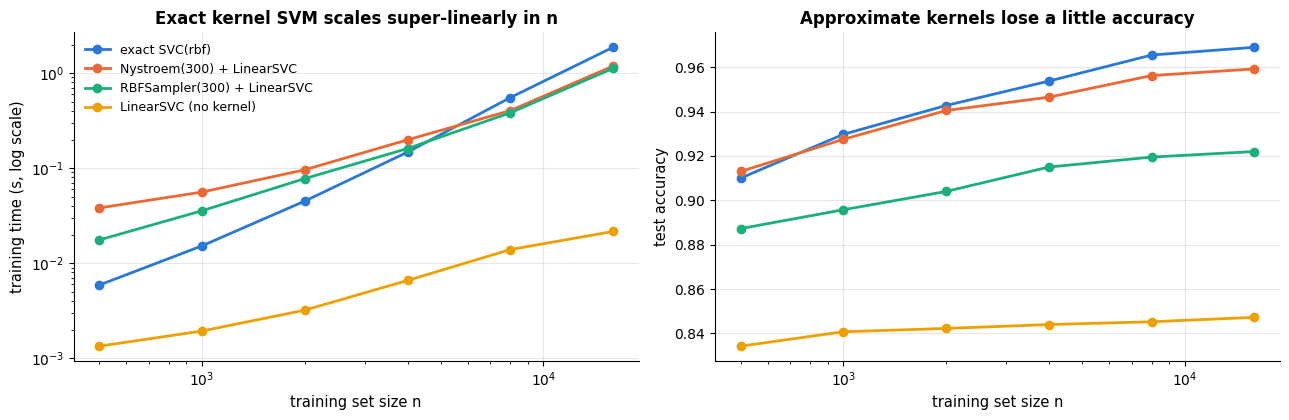

exact SVC(rbf)           ... LinearSVC (no kernel)         
             seconds accuracy  ...               seconds accuracy
500            0.006    0.910  ...                 0.001    0.834
1000           0.015    0.930  ...                 0.002    0.841
2000           0.045    0.943  ...                 0.003    0.842
4000           0.147    0.954  ...                 0.007    0.844
8000           0.553    0.966  ...                 0.014    0.845
16000          1.871    0.969  ...                 0.022    0.847

[6 rows x 8 columns]

In [16]:
from threadpoolctl import threadpool_limits          # ships with scikit-learn
from sklearn.datasets import make_classification
from sklearn.kernel_approximation import Nystroem, RBFSampler

X_big, y_big = make_classification(n_samples=20_000, n_features=20, n_informative=10, random_state=RANDOM_STATE)
X_big = StandardScaler().fit_transform(X_big)
X_big_test, y_big_test = X_big[16_000:], y_big[16_000:]
gamma_big = 1 / X_big.shape[1]

def timed_fit(model, n):
    t0 = time.perf_counter()
    model.fit(X_big[:n], y_big[:n])
    return time.perf_counter() - t0, model.score(X_big_test, y_big_test)

models_big = {
    "exact SVC(rbf)": lambda: SVC(kernel="rbf", gamma=gamma_big, C=1),
    "Nystroem(300) + LinearSVC": lambda: make_pipeline(Nystroem(gamma=gamma_big, n_components=300, random_state=RANDOM_STATE),
                                                       LinearSVC(C=1, dual=False)),
    "RBFSampler(300) + LinearSVC": lambda: make_pipeline(RBFSampler(gamma=gamma_big, n_components=300, random_state=RANDOM_STATE),
                                                         LinearSVC(C=1, dual=False)),
    "LinearSVC (no kernel)": lambda: LinearSVC(C=1, dual=False),
}
sizes = [500, 1000, 2000, 4000, 8000, 16_000]
timing = pd.DataFrame(index=sizes, columns=pd.MultiIndex.from_product([models_big, ["seconds", "accuracy"]]), dtype=float)
with threadpool_limits(limits=1):          # single-threaded BLAS: fair, reproducible timings
    for make in models_big.values():       # warm-up run, excluded from the timings
        timed_fit(make(), 500)
    for n in sizes:
        for name, make in models_big.items():
            timing.loc[n, (name, "seconds")], timing.loc[n, (name, "accuracy")] = timed_fit(make(), n)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.3))
for name in models_big:
    axes[0].plot(sizes, timing[(name, "seconds")], marker="o", label=name)
    axes[1].plot(sizes, timing[(name, "accuracy")], marker="o", label=name)
axes[0].set_xscale("log")
axes[0].set_yscale("log")
axes[0].set_xlabel("training set size n")
axes[0].set_ylabel("training time (s, log scale)")
axes[0].set_title("Exact kernel SVM scales super-linearly in n")
axes[0].legend(loc="upper left", fontsize=9)
axes[1].set_xscale("log")
axes[1].set_xlabel("training set size n")
axes[1].set_ylabel("test accuracy")
axes[1].set_title("Approximate kernels lose a little accuracy")
plt.tight_layout()
plt.show()
timing.round(3)

The exact SVM's cost grows roughly quadratically — doubling $n$ multiplies the time by
three to four — while the approximations grow linearly, so the curves cross at a few
thousand samples and the gap keeps widening. The Nyström features stay within about one
percentage point of the exact accuracy; random Fourier features with the same $D = 300$
lose a few points more (Nyström adapts its features to the data, random features do
not); the purely linear model is fastest but simply cannot represent this boundary. At
$n$ in the hundreds of thousands the exact solver is out of reach and the approximations
are the only kernel option; `n_components` controls the accuracy/time trade-off
(exercise 4).

## 5. Kernels for regression: SVR, kernel ridge and Gaussian processes

The same machinery — a kernel expansion $f(\mathbf{x}) = \sum_i \alpha_i k(\mathbf{x}_i, \mathbf{x}) + b$
fitted with a regularised loss — gives three regression methods that differ only in the
loss and in how they treat uncertainty.

### 5.1 Support vector regression

**SVR** (Vapnik, 1995; tutorial: Smola & Schölkopf, 2004) replaces the hinge loss with
the **$\varepsilon$-insensitive loss**

$$
\ell_\varepsilon(y, \hat{y}) = \max\big(0,\ |y - \hat{y}| - \varepsilon\big),
$$

which is zero inside a *tube* of half-width $\varepsilon$ around the prediction and grows
linearly outside it. The objective is $\tfrac12\|\mathbf{w}\|^2 + C\sum_i \ell_\varepsilon(y_i, f(\mathbf{x}_i))$,
and, exactly as for classification, only the points *on or outside* the tube become
support vectors with non-zero $\alpha_i$. $\varepsilon$ therefore controls sparsity: a
wider tube ignores more points. The linear-outside-the-tube loss also makes SVR robust to
outliers, like the Huber loss of notebook 6.

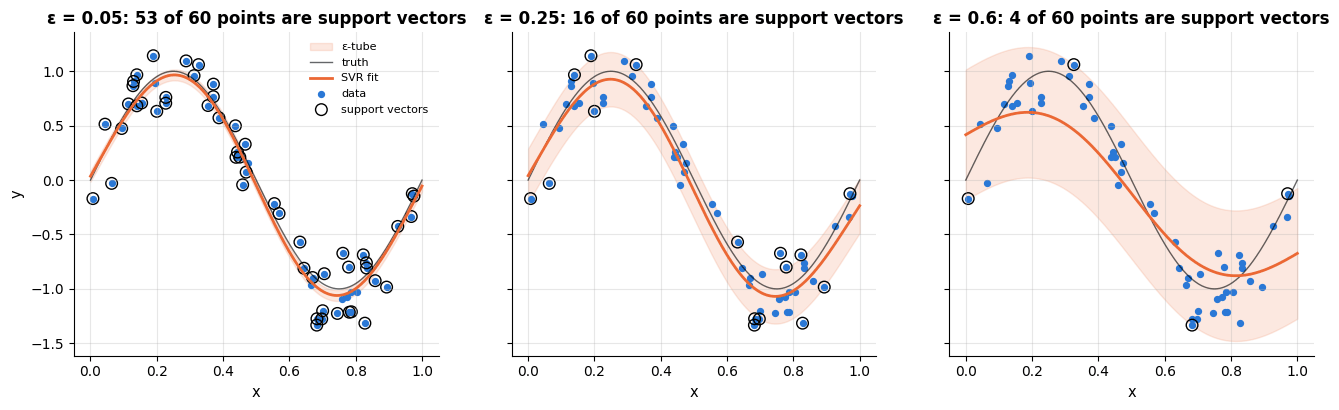

In [17]:
from sklearn.svm import SVR

x_r = np.sort(rng.uniform(0, 1, 60))
y_r = np.sin(2 * np.pi * x_r) + rng.normal(0, 0.25, len(x_r))
x_grid = np.linspace(0, 1, 300)[:, None]

fig, axes = plt.subplots(1, 3, figsize=(16, 4.2), sharey=True)
for ax, eps in zip(axes, [0.05, 0.25, 0.6]):
    svr = SVR(kernel="rbf", C=5, gamma=5, epsilon=eps).fit(x_r[:, None], y_r)
    pred = svr.predict(x_grid)
    ax.fill_between(x_grid.ravel(), pred - eps, pred + eps, color=PALETTE[1], alpha=0.15, label="ε-tube")
    ax.plot(x_grid, np.sin(2 * np.pi * x_grid), color="black", lw=1, alpha=0.6, label="truth")
    ax.plot(x_grid, pred, color=PALETTE[1], lw=2, label="SVR fit")
    ax.scatter(x_r, y_r, s=18, color=PALETTE[0], label="data")
    ax.scatter(x_r[svr.support_], y_r[svr.support_], s=70, facecolors="none", edgecolors="black", label="support vectors")
    ax.set_title(f"ε = {eps}: {len(svr.support_)} of {len(x_r)} points are support vectors")
    ax.set_xlabel("x")
axes[0].set_ylabel("y")
axes[0].legend(loc="upper right", fontsize=8)
plt.show()

### 5.2 Kernel ridge regression

**Kernel ridge regression** (KRR) keeps the squared loss of ridge regression (notebook 6)
and kernelises it. Ridge's solution $\mathbf{w} = (\mathbf{X}^\top\mathbf{X} + \lambda\mathbf{I})^{-1}\mathbf{X}^\top\mathbf{y}$
can be rewritten as $\mathbf{w} = \mathbf{X}^\top\boldsymbol{\alpha}$ with
$\boldsymbol{\alpha} = (\mathbf{X}\mathbf{X}^\top + \lambda\mathbf{I})^{-1}\mathbf{y}$ — and
$\mathbf{X}\mathbf{X}^\top$ is the matrix of dot products, i.e. the linear kernel matrix.
Replacing it by any kernel matrix gives

$$
\boldsymbol{\alpha} = (\mathbf{K} + \lambda\mathbf{I})^{-1}\mathbf{y},
\qquad
\hat{f}(\mathbf{x}) = \sum_{i=1}^n \alpha_i\, k(\mathbf{x}_i, \mathbf{x}) .
$$

Unlike SVR, KRR has a **closed form** (one $n \times n$ linear solve, $O(n^3)$), no
$\varepsilon$, and it is *dense*: every training point has a non-zero coefficient, so
prediction costs $O(n d)$ instead of $O(n_{\text{SV}} d)$. Four lines of NumPy suffice:

max |KRR by hand - KernelRidge| = 6.2e-15
non-zero coefficients: KRR 60 of 60   SVR 16 of 60


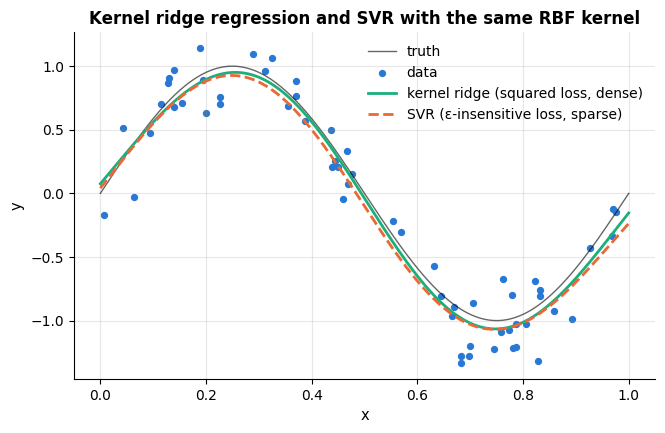

In [18]:
from sklearn.kernel_ridge import KernelRidge

lam_krr, gamma_krr = 0.1, 5.0
K_train = rbf_kernel(x_r[:, None], gamma=gamma_krr)
alpha_krr = np.linalg.solve(K_train + lam_krr * np.eye(len(x_r)), y_r)          # (K + λI)^{-1} y
pred_hand = rbf_kernel(x_grid, x_r[:, None], gamma=gamma_krr) @ alpha_krr        # sum_i alpha_i k(x_i, x)

krr = KernelRidge(alpha=lam_krr, kernel="rbf", gamma=gamma_krr).fit(x_r[:, None], y_r)
svr = SVR(kernel="rbf", C=5, gamma=gamma_krr, epsilon=0.25).fit(x_r[:, None], y_r)
print(f"max |KRR by hand - KernelRidge| = {np.abs(pred_hand - krr.predict(x_grid)).max():.1e}")
print(f"non-zero coefficients: KRR {np.sum(np.abs(krr.dual_coef_) > 1e-12)} of {len(x_r)}   SVR {len(svr.support_)} of {len(x_r)}")

fig, ax = plt.subplots()
ax.plot(x_grid, np.sin(2 * np.pi * x_grid), color="black", lw=1, alpha=0.6, label="truth")
ax.scatter(x_r, y_r, s=18, color=PALETTE[0], label="data")
ax.plot(x_grid, krr.predict(x_grid), lw=2, color=PALETTE[2], label="kernel ridge (squared loss, dense)")
ax.plot(x_grid, svr.predict(x_grid), lw=2, color=PALETTE[1], ls="--", label="SVR (ε-insensitive loss, sparse)")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("Kernel ridge regression and SVR with the same RBF kernel")
ax.legend()
plt.show()

### 5.3 A glimpse of Gaussian processes

A **Gaussian process** (GP; Rasmussen & Williams, 2006) is the Bayesian reading of the
same kernel. Instead of a penalty, the kernel now defines a *prior over functions*:
$f \sim \mathcal{GP}(0, k)$ means that for any set of inputs the function values
$(f(\mathbf{x}_1), \dots, f(\mathbf{x}_n))$ are jointly Gaussian with covariance matrix
$\mathbf{K}$. The kernel encodes our beliefs: an RBF kernel with length-scale $\ell$ says
"smooth functions that vary on the scale $\ell$". Observing $y_i = f(\mathbf{x}_i) + \varepsilon_i$
with $\varepsilon_i \sim \mathcal{N}(0, \sigma_n^2)$ and conditioning the Gaussian gives
the posterior at a new point $\mathbf{x}_*$ in closed form:

$$
\mathbb{E}[f(\mathbf{x}_*) \mid \mathcal{D}] = \mathbf{k}_*^\top(\mathbf{K} + \sigma_n^2\mathbf{I})^{-1}\mathbf{y},
\qquad
\operatorname{Var}[f(\mathbf{x}_*) \mid \mathcal{D}] = k(\mathbf{x}_*, \mathbf{x}_*) - \mathbf{k}_*^\top(\mathbf{K} + \sigma_n^2\mathbf{I})^{-1}\mathbf{k}_* ,
$$

where $\mathbf{k}_* = (k(\mathbf{x}_1, \mathbf{x}_*), \dots, k(\mathbf{x}_n, \mathbf{x}_*))^\top$.
The posterior mean is *exactly* kernel ridge regression with $\lambda = \sigma_n^2$ — but
the GP adds two things KRR lacks: a **predictive variance** that grows away from the
data, and a principled way to choose the kernel hyper-parameters (length-scale, signal and
noise variances) by maximising the **marginal likelihood** $p(\mathbf{y} \mid \mathbf{X}, \boldsymbol{\theta})$
instead of by cross-validation. We remove the middle of the training data and predict
beyond its ends to see the uncertainty react.

max |GP posterior mean - kernel ridge| = 4.4e-10
fitted kernel: 0.709**2 * RBF(length_scale=0.174) + WhiteKernel(noise_level=0.0447)


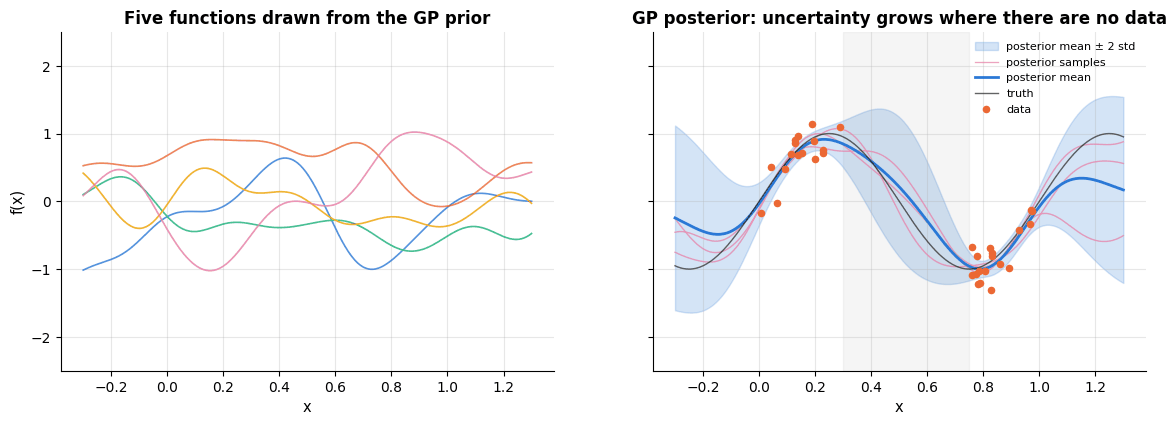

In [19]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel, ConstantKernel

keep = (x_r < 0.3) | (x_r > 0.75)                                # remove the middle: a region without data
x_gp, y_gp = x_r[keep][:, None], y_r[keep]
x_wide = np.linspace(-0.3, 1.3, 400)[:, None]                    # predict beyond the data range as well

# 1) fixed kernel: the GP posterior mean must coincide with kernel ridge regression (λ = σ_n²)
sigma_n2, length = 0.25 ** 2, 0.15
gp_fixed = GaussianProcessRegressor(kernel=RBF(length_scale=length) + WhiteKernel(noise_level=sigma_n2), optimizer=None).fit(x_gp, y_gp)
krr_same = KernelRidge(alpha=sigma_n2, kernel="rbf", gamma=1 / (2 * length**2)).fit(x_gp, y_gp)
print(f"max |GP posterior mean - kernel ridge| = {np.abs(gp_fixed.predict(x_wide) - krr_same.predict(x_wide)).max():.1e}")

# 2) hyper-parameters (signal variance, length-scale, noise) learned by maximising the marginal likelihood
kernel = ConstantKernel(1.0) * RBF(length_scale=0.2) + WhiteKernel(noise_level=0.1)
gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=5, random_state=RANDOM_STATE).fit(x_gp, y_gp)
print("fitted kernel:", gp.kernel_)
# the same GP with the learned noise passed as `alpha`: its posterior is over the noise-free function f, not over y
signal_kernel, noise_level = gp.kernel_.k1, gp.kernel_.k2.noise_level
gp_f = GaussianProcessRegressor(kernel=signal_kernel, alpha=noise_level, optimizer=None).fit(x_gp, y_gp)
mean, std = gp_f.predict(x_wide, return_std=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.4), sharey=True)
prior = GaussianProcessRegressor(kernel=signal_kernel)          # same kernel, no data: the prior
for s in prior.sample_y(x_wide, n_samples=5, random_state=RANDOM_STATE).T:
    axes[0].plot(x_wide, s, lw=1.2, alpha=0.8)
axes[0].set_title("Five functions drawn from the GP prior")
axes[0].set_xlabel("x")
axes[0].set_ylabel("f(x)")
axes[1].fill_between(x_wide.ravel(), mean - 2 * std, mean + 2 * std, color=PALETTE[0], alpha=0.2, label="posterior mean ± 2 std")
for i, s in enumerate(gp_f.sample_y(x_wide, n_samples=3, random_state=RANDOM_STATE).T):
    axes[1].plot(x_wide, s, lw=1, alpha=0.7, color=PALETTE[4], label="posterior samples" if i == 0 else None)
axes[1].plot(x_wide, mean, lw=2, color=PALETTE[0], label="posterior mean")
axes[1].plot(x_wide, np.sin(2 * np.pi * x_wide), color="black", lw=1, alpha=0.6, label="truth")
axes[1].scatter(x_gp, y_gp, s=20, color=PALETTE[1], zorder=3, label="data")
axes[1].axvspan(0.3, 0.75, color="gray", alpha=0.08)
axes[1].set_title("GP posterior: uncertainty grows where there are no data")
axes[1].set_xlabel("x")
axes[1].set_ylim(-2.5, 2.5)
axes[1].legend(loc="upper right", fontsize=8)
plt.show()

The band is narrow near the observations, widens in the gap (shaded) and grows to the
prior's width beyond the ends of the data, where the posterior mean also reverts towards
the prior mean of zero — the GP *knows what it does not know*. This calibrated
uncertainty is what makes GPs the workhorse of **Bayesian optimisation** (notebook 12)
and of small-data science and engineering problems. The price is the same $O(n^3)$ solve
as KRR, which limits exact GPs to a few thousand points (sparse approximations exist;
Rasmussen & Williams, 2006, ch. 8).

## 6. Strengths, weaknesses and when to use them

Three related models have been built in this notebook — the linear SVM, the kernel SVM and
support vector regression — and they fail in different ways. This section states the
judgement for each, and then *demonstrates* three of the weaknesses rather than merely
asserting them.

### 6.1 The linear SVM (`SVC(kernel="linear")`, `LinearSVC`)

| | |
|---|---|
| **Assumptions / inductive bias** | the classes are (nearly) separable by a hyperplane, and among the many separating hyperplanes the one with the widest margin generalises best; all features are on comparable scales |
| **Strengths** | convex problem with a unique optimum; the margin *is* an $L_2$ regulariser, so it copes with $d \gg n$; sparse in the training points (only support vectors matter); `LinearSVC`/`SGDClassifier` train in $O(nd)$ and scale to millions of rows and sparse features; excellent on high-dimensional text (notebook 15) |
| **Weaknesses / failure modes** | only a linear boundary — useless on the circles of section 3.3 without a kernel; no probabilities without an extra calibration step (section 4.2); sensitive to feature scaling because the margin is measured in Euclidean distance; the hinge loss is not differentiable, so the optimiser needs sub-gradients or a dual solver; coefficients are hard to interpret when features are correlated |
| **Data it suits** | any $n$; $d$ from a handful to millions (sparse); numeric, standardised features; few missing values (impute first); moderate label noise |
| **Complexity** | `LinearSVC`: training $O(nd)$, memory $O(nd)$ (sparse-friendly); `SVC(kernel="linear")`: the dual, so $O(n^2 d)$–$O(n^3 d)$; prediction $O(d)$ for both |
| **Interpretability** | moderate: `coef_` is a weight per feature (sign and magnitude readable after standardisation), and the support vectors show which training points determine the boundary |
| **Use it when** | $d$ is large relative to $n$, the signal is close to linear, or $n$ is too large for a kernel |
| **Avoid it when** | the boundary is genuinely curved and you cannot engineer features for it — use a kernel, or trees (notebook 10) |

### 6.2 The kernel SVM (`SVC(kernel="rbf"/"poly")`)

| | |
|---|---|
| **Assumptions / inductive bias** | the decision function is smooth in the geometry defined by the kernel — for the RBF kernel, points within a distance $\sigma = 1/\sqrt{2\gamma}$ of each other should get similar labels; the Euclidean distance between feature vectors is meaningful |
| **Strengths** | represents highly non-linear boundaries without ever building the feature map; very strong on small-to-medium, homogeneous, continuous data (pixels, spectra, embeddings); the same code works for any Mercer kernel, including kernels on strings and graphs; margin theory bounds the error independently of the feature-space dimension; robust to $d > n$ |
| **Weaknesses / failure modes** | training is $O(n^2 d)$–$O(n^3 d)$ with $O(n^2)$ memory — the wall of section 6.4; prediction cost grows with the number of support vectors, which grows *linearly* with $n$; a large $\gamma$ memorises the training set (section 6.5); unusable without feature scaling (section 6.6); two interacting hyper-parameters must be tuned; no probabilities, no feature importances, nothing to read off the fitted model |
| **Data it suits** | $n$ from a hundred to a few tens of thousands; $d$ from 2 to a few thousand; continuous features on a common scale; poor fit for heterogeneous tabular data with categoricals and missing values |
| **Complexity** | training $O(n^2 d)$–$O(n^3 d)$, memory $O(n^2)$ for the kernel cache, prediction $O(n_{\text{SV}} d)$ per sample |
| **Interpretability** | low: the fitted model is a weighted sum of kernels centred on support vectors. Use permutation importance or the tools of notebook 17 if you need explanations |
| **Use it when** | $n \lesssim 10^4$, the features are homogeneous and continuous, and the boundary is non-linear |
| **Avoid it when** | $n$ is large, the columns are mixed types with missing values, calibrated probabilities are the product, or you must explain individual decisions |

### 6.3 Support vector regression (`SVR`)

| | |
|---|---|
| **Assumptions / inductive bias** | the regression function is smooth in the kernel geometry, and errors smaller than $\varepsilon$ do not matter at all |
| **Strengths** | the $\varepsilon$-insensitive loss is linear outside the tube, so outliers pull far less than under a squared loss; sparse — only points on or outside the tube are support vectors, so prediction is cheap; the same kernels as for classification; $\varepsilon$ is a direct, interpretable statement about the precision you need |
| **Weaknesses / failure modes** | three hyper-parameters ($C$, $\gamma$, $\varepsilon$) instead of one; no predictive uncertainty (use a Gaussian process, section 5.3); no closed form, so it is slower to fit than kernel ridge on the same data; same $O(n^2)$–$O(n^3)$ wall; the target must be scaled too, because $\varepsilon$ is in the units of $y$ |
| **Data it suits** | small-to-medium $n$, continuous scaled features **and** a scaled target, smooth response, possibly heavy-tailed noise |
| **Complexity** | as for `SVC`; `KernelRidge` is a single $O(n^3)$ solve and is usually faster below a few thousand points, but its solution is dense |
| **Interpretability** | low, as for the kernel SVM; the tube width $\varepsilon$ and the support-vector count are the readable quantities |
| **Use it when** | you want a robust non-linear regressor on modest data and can state a tolerance $\varepsilon$ |
| **Avoid it when** | you need uncertainty (GP), a closed form (kernel ridge), extrapolation beyond the data (no kernel method extrapolates), or $n$ is large (boosting, notebook 10) |

### 6.4 Demonstrated failure 1: the $O(n^2)$–$O(n^3)$ wall

The complexity claim is the single most consequential thing about kernel SVMs, so let us
measure it instead of quoting it. We fit `SVC(kernel="rbf")` on a deliberately noisy
20-dimensional problem (many points end up inside the margin, which is the realistic case)
for training sets of growing size, and record the fit time, the number of support vectors
and the time to score 1 000 new rows.

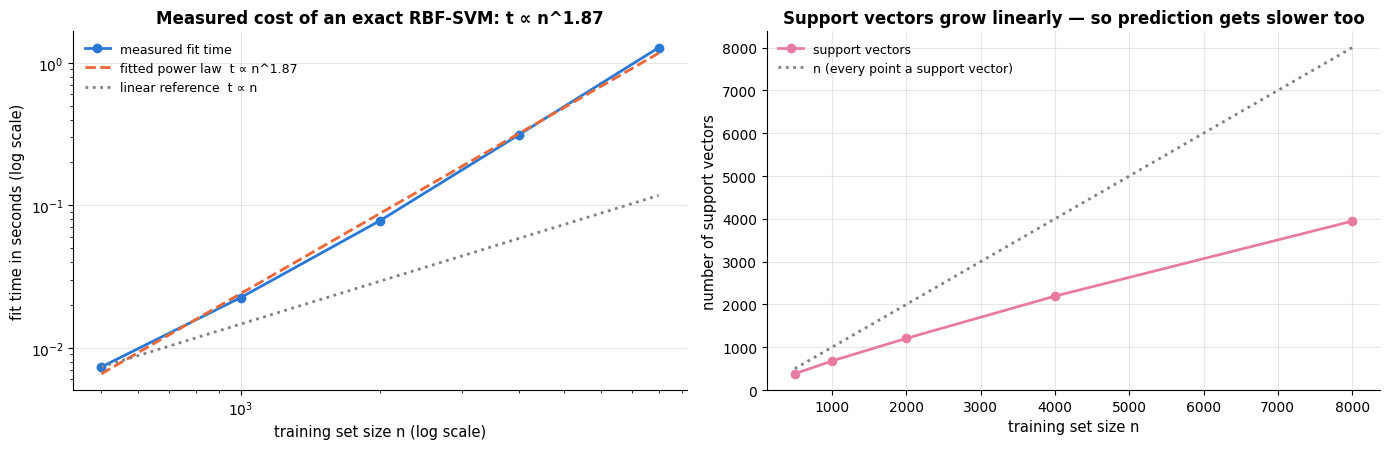

extrapolated fit time at n = 1e+05:    0.0 hours; kernel matrix 80 GB
extrapolated fit time at n = 1e+06:    2.7 hours; kernel matrix 8,000 GB


,fit time (s),support vectors,SV fraction,score 1000 rows (s),kernel matrix (MB)
n,,,,,
500,0.007,380,0.760,0.018,2.0
1000,0.023,680,0.680,0.031,8.0
2000,0.078,1208,0.604,0.054,32.0
4000,0.314,2194,0.548,0.105,128.0
8000,1.279,3946,0.493,0.177,512.0


In [20]:
X_wall, y_wall = make_classification(n_samples=12_000, n_features=20, n_informative=8,
                                     class_sep=0.8, flip_y=0.10, random_state=RANDOM_STATE)
X_wall = StandardScaler().fit_transform(X_wall)

wall_rows = []
with threadpool_limits(limits=1):                       # single-threaded: comparable timings
    SVC(kernel="rbf", C=1).fit(X_wall[:300], y_wall[:300])        # warm-up, not timed
    for n in [500, 1000, 2000, 4000, 8000]:
        model = SVC(kernel="rbf", C=1)
        t0 = time.perf_counter(); model.fit(X_wall[:n], y_wall[:n]); fit_s = time.perf_counter() - t0
        t0 = time.perf_counter(); model.predict(X_wall[10_000:11_000]); pred_s = time.perf_counter() - t0
        wall_rows.append({"n": n, "fit time (s)": fit_s, "support vectors": int(model.n_support_.sum()),
                          "SV fraction": model.n_support_.sum() / n, "score 1000 rows (s)": pred_s,
                          "kernel matrix (MB)": n * n * 8 / 1e6})
wall = pd.DataFrame(wall_rows).set_index("n")

log_n, log_t = np.log(wall.index.values.astype(float)), np.log(wall["fit time (s)"].values)
slope, intercept = np.polyfit(log_n, log_t, 1)          # fit  time ≈ a · n^slope

fig, axes = plt.subplots(1, 2, figsize=(14, 4.6))
axes[0].plot(wall.index, wall["fit time (s)"], "o-", color=PALETTE[0], label="measured fit time")
axes[0].plot(wall.index, np.exp(intercept) * wall.index.values.astype(float) ** slope, ls="--", color=PALETTE[1],
             label=f"fitted power law  t ∝ n^{slope:.2f}")
axes[0].plot(wall.index, wall["fit time (s)"].iloc[0] * wall.index / wall.index[0], ls=":", color="gray",
             label="linear reference  t ∝ n")
axes[0].set_xscale("log"); axes[0].set_yscale("log")
axes[0].set_xlabel("training set size n (log scale)"); axes[0].set_ylabel("fit time in seconds (log scale)")
axes[0].set_title(f"Measured cost of an exact RBF-SVM: t ∝ n^{slope:.2f}"); axes[0].legend(fontsize=9)
axes[1].plot(wall.index, wall["support vectors"], "o-", color=PALETTE[4], label="support vectors")
axes[1].plot(wall.index, wall.index, ls=":", color="gray", label="n (every point a support vector)")
axes[1].set_xlabel("training set size n"); axes[1].set_ylabel("number of support vectors")
axes[1].set_title("Support vectors grow linearly — so prediction gets slower too")
axes[1].legend(fontsize=9)
plt.tight_layout()
plt.show()
for n_future in [1e5, 1e6]:
    print(f"extrapolated fit time at n = {n_future:.0e}: {np.exp(intercept) * n_future ** slope / 3600:6.1f} hours; "
          f"kernel matrix {n_future ** 2 * 8 / 1e9:,.0f} GB")
wall.round(3)

The fitted exponent is close to $2$: **doubling the data multiplies the training time by
three to four**, and it keeps doing so for ever. The extrapolation printed under the figure
turns that into wall-clock time — the fit that takes under three seconds at $n = 8\,000$
runs for hours at $n = 10^6$ — and the memory is worse still, because the kernel matrix needs $8n^2$
bytes: 8 GB at $n = 3 \times 10^4$ and 8 TB at $n = 10^6$. The right-hand panel shows the second
half of the problem: the number of support vectors grows linearly with $n$, so *prediction*
also becomes linearly slower as the training set grows. This is not a tuning issue that a
better grid could fix; it is the algorithm. The remedies are the ones of section 4.3 —
`LinearSVC`/`SGDClassifier`, or `Nystroem`/`RBFSampler` plus a linear model.

### 6.5 Demonstrated failure 2: a large $\gamma$ memorises the training set

Section 3.4 showed the $(\gamma, C)$ grid of decision boundaries. Here is the same failure
quantitatively: as $\gamma$ grows, each Gaussian bump shrinks until it covers only its own
training point, so the model can label the training set perfectly while learning nothing
that transfers.

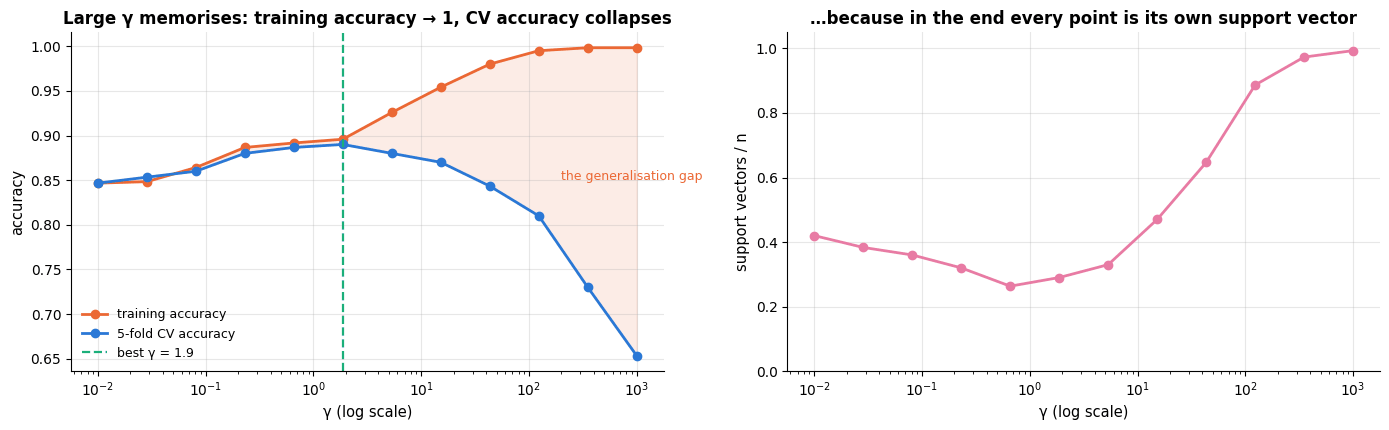

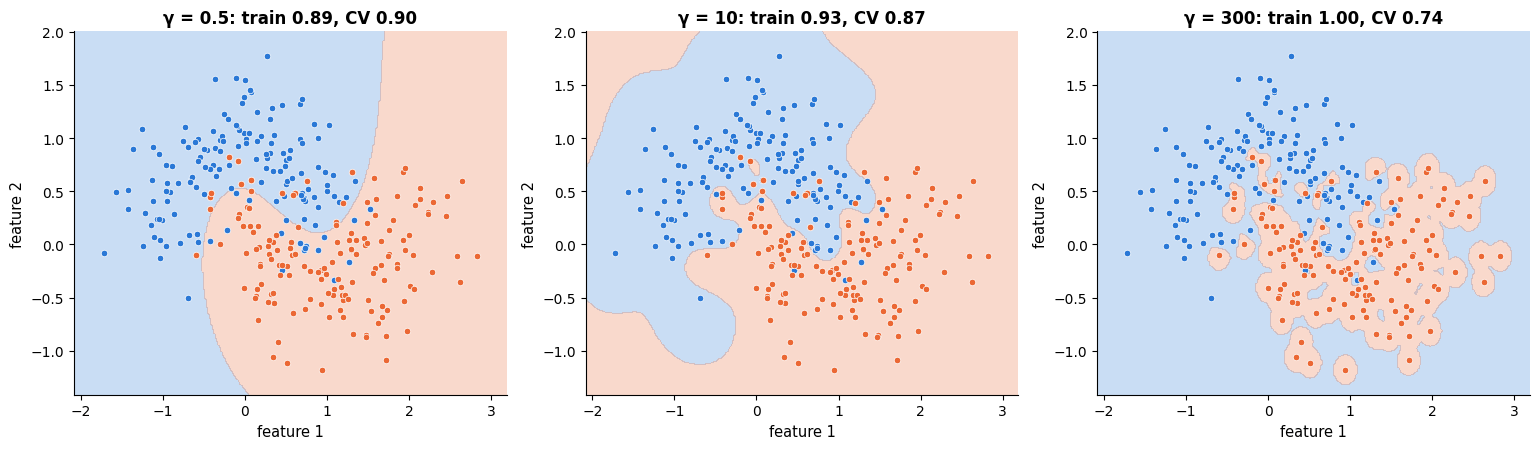

In [21]:
from sklearn.model_selection import cross_validate

gamma_fail = np.logspace(-2, 3, 12)
fail_rows = []
for g in gamma_fail:
    scored = cross_validate(SVC(kernel="rbf", C=10, gamma=g), X_moon, y_moon, cv=cv, return_train_score=True)
    fitted = SVC(kernel="rbf", C=10, gamma=g).fit(X_moon, y_moon)
    fail_rows.append({"gamma": g, "train": scored["train_score"].mean(), "cv": scored["test_score"].mean(),
                      "sv_fraction": fitted.n_support_.sum() / len(X_moon)})
fail = pd.DataFrame(fail_rows).set_index("gamma")

fig, axes = plt.subplots(1, 2, figsize=(14, 4.4))
axes[0].plot(fail.index, fail["train"], "-o", color=PALETTE[1], label="training accuracy")
axes[0].plot(fail.index, fail["cv"], "-o", color=PALETTE[0], label="5-fold CV accuracy")
axes[0].fill_between(fail.index, fail["cv"], fail["train"], color=PALETTE[1], alpha=0.12)
axes[0].axvline(fail["cv"].idxmax(), color=PALETTE[2], ls="--", lw=1.6, label=f"best γ = {fail['cv'].idxmax():.2g}")
axes[0].annotate("the generalisation gap", xy=(200, 0.85), fontsize=9, color=PALETTE[1])
axes[0].set_xscale("log"); axes[0].set_xlabel("γ (log scale)"); axes[0].set_ylabel("accuracy")
axes[0].set_title("Large γ memorises: training accuracy → 1, CV accuracy collapses")
axes[0].legend(fontsize=9, loc="lower left")
axes[1].plot(fail.index, fail["sv_fraction"], "-o", color=PALETTE[4])
axes[1].set_xscale("log"); axes[1].set_ylim(0, 1.05)
axes[1].set_xlabel("γ (log scale)"); axes[1].set_ylabel("support vectors / n")
axes[1].set_title("…because in the end every point is its own support vector")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(15.5, 4.6))
for ax, g in zip(axes, [0.5, 10, 300]):
    model = SVC(kernel="rbf", C=10, gamma=g).fit(X_moon, y_moon)
    plot_decision_boundary(model, X_moon, y_moon, ax=ax, legend=False,
                           title=f"γ = {g}: train {model.score(X_moon, y_moon):.2f}, "
                                 f"CV {cross_val_score(model, X_moon, y_moon, cv=cv).mean():.2f}")
plt.tight_layout()
plt.show()

At $\gamma = 1000$ the model is right on 99.8 % of the points it was shown and on about 65 %
of the points it was not: one new point in three misclassified, on data where the same model
with $\gamma \approx 2$ gets 89 % right. The middle
panel of the second figure is the interesting one: at $\gamma = 10$ the boundary has already
started growing lobes around small clumps of points, and the training accuracy (0.93) still
looks respectable even though the CV accuracy (0.87) has begun to fall.
**Training accuracy cannot detect this failure; only a validation score can.** Note also
that a large $C$ makes it worse (it forbids the violations that would smooth the boundary),
which is exactly why $C$ and $\gamma$ must be tuned together.

### 6.6 Demonstrated failure 3: features on different scales

Section 4.1 measured what scaling is worth across all 30 breast-cancer features. In two
dimensions we can *see* why. `worst smoothness` lies in $[0.07, 0.22]$ and `worst area` in
$[185, 3432]$ — a ratio of about $10^4$. The RBF kernel
$\exp(-\gamma\|\mathbf{x}-\mathbf{z}\|^2)$ measures distance with both, so the squared
difference in area swamps the squared difference in smoothness by eight orders of
magnitude, and the fitted boundary simply ignores one of the two features.

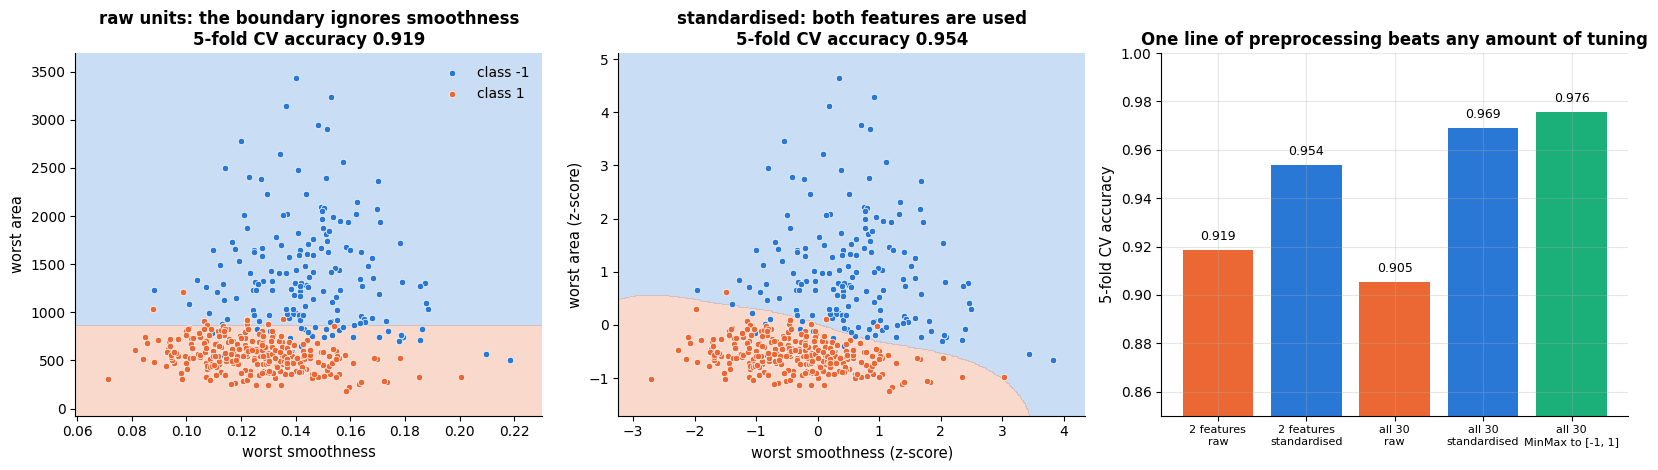

In [22]:
from sklearn.preprocessing import MinMaxScaler

pair_names = ["worst smoothness", "worst area"]
pair = [cancer.feature_names.tolist().index(name) for name in pair_names]
X_pair = X_c_train[:, pair]
X_pair_scaled = StandardScaler().fit_transform(X_pair)

acc_raw = cross_val_score(SVC(), X_pair, y_c_train, cv=cv).mean()
acc_std = cross_val_score(make_pipeline(StandardScaler(), SVC()), X_pair, y_c_train, cv=cv).mean()

fig, axes = plt.subplots(1, 3, figsize=(16.5, 4.8))
plot_decision_boundary(SVC().fit(X_pair, y_c_train), X_pair, y_c_train, ax=axes[0], feature_names=pair_names,
                       title=f"raw units: the boundary ignores smoothness\n5-fold CV accuracy {acc_raw:.3f}")
plot_decision_boundary(SVC().fit(X_pair_scaled, y_c_train), X_pair_scaled, y_c_train, ax=axes[1], legend=False,
                       feature_names=[f"{name} (z-score)" for name in pair_names],
                       title=f"standardised: both features are used\n5-fold CV accuracy {acc_std:.3f}")
bars = {"2 features\nraw": acc_raw, "2 features\nstandardised": acc_std,
        "all 30\nraw": cross_val_score(SVC(), X_c_train, y_c_train, cv=cv).mean(),
        "all 30\nstandardised": cross_val_score(make_pipeline(StandardScaler(), SVC()), X_c_train, y_c_train, cv=cv).mean(),
        "all 30\nMinMax to [-1, 1]": cross_val_score(make_pipeline(MinMaxScaler((-1, 1)), SVC()), X_c_train, y_c_train, cv=cv).mean()}
axes[2].bar(range(len(bars)), list(bars.values()), color=[PALETTE[1], PALETTE[0], PALETTE[1], PALETTE[0], PALETTE[2]])
for i, v in enumerate(bars.values()):
    axes[2].text(i, v + 0.004, f"{v:.3f}", ha="center", fontsize=9)
axes[2].set_xticks(range(len(bars)))
axes[2].set_xticklabels(list(bars), fontsize=8)
axes[2].set_ylim(0.85, 1.0)
axes[2].set_ylabel("5-fold CV accuracy")
axes[2].set_title("One line of preprocessing beats any amount of tuning")
plt.tight_layout()
plt.show()

The left panel's boundary is a horizontal line: the classifier is a threshold on area alone,
because in raw units that is the only feature the kernel can see. Standardising makes the
boundary curve in both directions and buys three accuracy points in 2-D and six across all
30 features — more than the difference between any two models in the case study of
section 8, and obtained for free.

> **Warning.** This is the single most common way to get a disappointing SVM. The default
> `gamma="scale"` divides by the *overall* variance of the data, which rescues the model
> from a global unit choice (metres instead of millimetres) but does nothing about
> differences *between* columns. Put a scaler in the pipeline; always.

## 7. Tuning guide

An SVM has few hyper-parameters, but they interact, and the wrong choice does not degrade
the model gracefully — it destroys it (section 6.5). This section is the recipe, with a
picture for every knob. Everything is measured on the breast-cancer *training* set with the
5-fold stratified `cv` defined in section 3.4; the test set stays untouched until section 8.

| Hyper-parameter | Controls | Range / scale | Bias–variance | Default |
|---|---|---|---|---|
| `kernel` | the geometry of the feature space | `"rbf"`, `"linear"`, `"poly"`, `"sigmoid"` (categorical) | rbf/poly lower bias than linear | `"rbf"` |
| `C` | price of a margin violation ($\lambda = 1/(nC)$) | $10^{-3}$ … $10^{4}$, **log** | ↑ `C` → ↓ bias, ↑ variance | `1.0` |
| `gamma` | RBF/poly kernel width, $\gamma = 1/(2\sigma^2)$ | $10^{-5}$ … $10^{1}$ after standardising, **log** | ↑ `gamma` → ↓ bias, ↑ variance | `"scale"` $= 1/(d\operatorname{Var}\mathbf{X})$ |
| `degree` | polynomial degree $p$ | 2, 3, 4 (5+ is rarely useful) | ↑ degree → ↓ bias, ↑ variance | `3` |
| `coef0` | the constant $r$ in the poly/sigmoid kernel | $0$ … $10^{2}$, **log-ish**; `poly` needs $r > 0$ | ↑ `coef0` → more weight on low-order terms | `0.0` |
| `epsilon` (SVR) | half-width of the insensitive tube, in units of $y$ | $0$ … a few $\times$ noise $\sigma$, linear | ↑ `epsilon` → ↑ bias, sparser | `0.1` |
| `class_weight` | per-class multiplier on `C` | `None` or `"balanced"` or a dict | moves the boundary, not the capacity | `None` |
| `tol`, `cache_size`, `shrinking` | solver accuracy, memory, heuristics | — | none (speed only) | `1e-3`, `200` MB, `True` |
| `probability` | fit Platt scaling as well | `True`/`False` | none (adds ~5× training time) | `False` |

**Tune in this order.**

1. **Scale the features** (section 6.6). This is not a hyper-parameter, it is a
   precondition; without it every number below is meaningless. Put `StandardScaler` (or
   `MinMaxScaler` to $[-1, 1]$, the LIBSVM guide's choice) inside the pipeline.
2. **`C` and `gamma` jointly**, on a logarithmic grid. They are the only two that usually
   matter, and their effects cancel — which is why a one-at-a-time search is not enough
   (section 7.2).
3. **The kernel**, if the RBF result is disappointing or $d$ is very large (section 7.3).
   With `"poly"`, `coef0` matters far more than `degree` (section 7.4).
4. **`class_weight`** if the classes are imbalanced — *after* `C` and `gamma`, and against a
   metric that is not accuracy (section 7.6).
5. **`epsilon`** for SVR, which is genuinely a third dimension (section 7.5).

### 7.1 Validation curves for `C` and `gamma`

The first look at any hyper-parameter is a validation curve: cross-validated score against
the parameter on a log axis, with the standard error of the mean as a band, so that we can
see whether the differences we are about to act on are real.

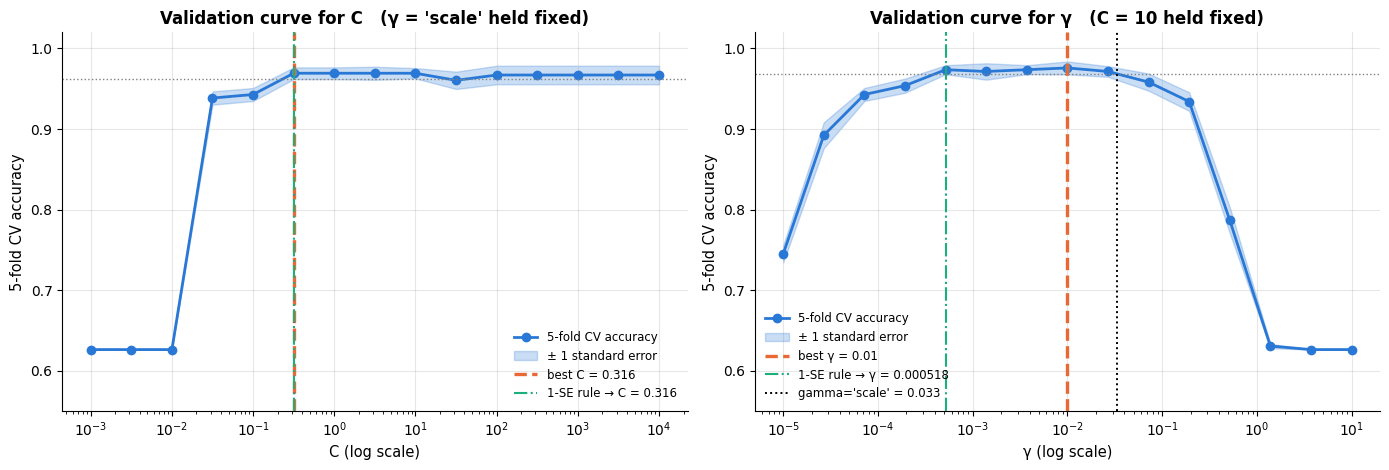

In [23]:
def cv_curve(param, values, **fixed):
    """5-fold CV accuracy (mean, standard error) of the scaled RBF-SVM as one hyper-parameter varies."""
    out = []
    for v in values:
        s = cross_val_score(make_pipeline(StandardScaler(), SVC(**{**fixed, param: v})), X_c_train, y_c_train, cv=cv)
        out.append((s.mean(), s.std(ddof=1) / np.sqrt(len(s))))
    return np.array(out)

C_range, gamma_range = np.logspace(-3, 4, 15), np.logspace(-5, 1, 15)
curve_C = cv_curve("C", C_range, gamma="scale")
curve_gamma = cv_curve("gamma", gamma_range, C=10)
gamma_scale = 1 / (X_c_train.shape[1] * StandardScaler().fit_transform(X_c_train).var())   # the "scale" default

fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
for ax, values, curve, label, held in [(axes[0], C_range, curve_C, "C", "γ = 'scale'"),
                                       (axes[1], gamma_range, curve_gamma, "γ", "C = 10")]:
    ax.plot(values, curve[:, 0], "-o", color=PALETTE[0], label="5-fold CV accuracy")
    ax.fill_between(values, curve[:, 0] - curve[:, 1], curve[:, 0] + curve[:, 1], color=PALETTE[0], alpha=0.25,
                    label="± 1 standard error")
    best = int(np.argmax(curve[:, 0]))
    floor = curve[best, 0] - curve[best, 1]                       # one-standard-error threshold
    simplest = values[np.flatnonzero(curve[:, 0] >= floor)[0]]    # smallest (= smoothest) value within 1 SE
    ax.axvline(values[best], color=PALETTE[1], ls="--", lw=2.4, label=f"best {label} = {values[best]:.3g}")
    ax.axvline(simplest, color=PALETTE[2], ls="-.", lw=1.5, label=f"1-SE rule → {label} = {simplest:.3g}")
    ax.axhline(floor, color="gray", ls=":", lw=1)
    ax.set_xscale("log"); ax.set_ylim(0.55, 1.02)
    ax.set_xlabel(f"{label} (log scale)")
    ax.set_ylabel("5-fold CV accuracy")
    ax.set_title(f"Validation curve for {label}   ({held} held fixed)")
axes[1].axvline(gamma_scale, color="black", ls=":", lw=1.4, label=f"gamma='scale' = {gamma_scale:.3f}")
axes[0].legend(fontsize=8.5, loc="lower right")
axes[1].legend(fontsize=8.5, loc="lower left")
plt.tight_layout()
plt.show()

Both curves have the shape to expect. `C` rises steeply out of a useless region (at
$C \le 0.01$ the penalty dominates and the model predicts the majority class, 62.6 %)
and then *plateaus* for four decades: once the margin is allowed to be narrow enough, making
violations even more expensive changes nothing. `gamma` has a genuine interior optimum with
cliffs on both sides — too small and the kernel is effectively linear, too large and we are
in the memorisation regime of section 6.5.

The one-standard-error rule (notebook 5, §4.3) behaves differently on the two: for `C` the
simplest value within one SE of the best *is* the best, so the rule changes nothing; for
`gamma` it moves us from $10^{-2}$ down to $5 \times 10^{-4}$, an order of magnitude towards
the smoother model, at no measurable cost in accuracy. When in doubt, take the smoother one.
Note also where `gamma="scale"` lands: on this data it is a perfectly reasonable starting
point, close to the plateau but not on its maximum — a good default, not a substitute for
tuning.

### 7.2 The canonical figure: the `C` × `gamma` heat map

Validation curves taken one at a time are misleading here, because the value of `C` at which
the left panel plateaus depends on the `gamma` we happened to hold fixed. The joint picture
is the heat map, and it is worth reading carefully: this is the single most useful figure in
SVM practice.

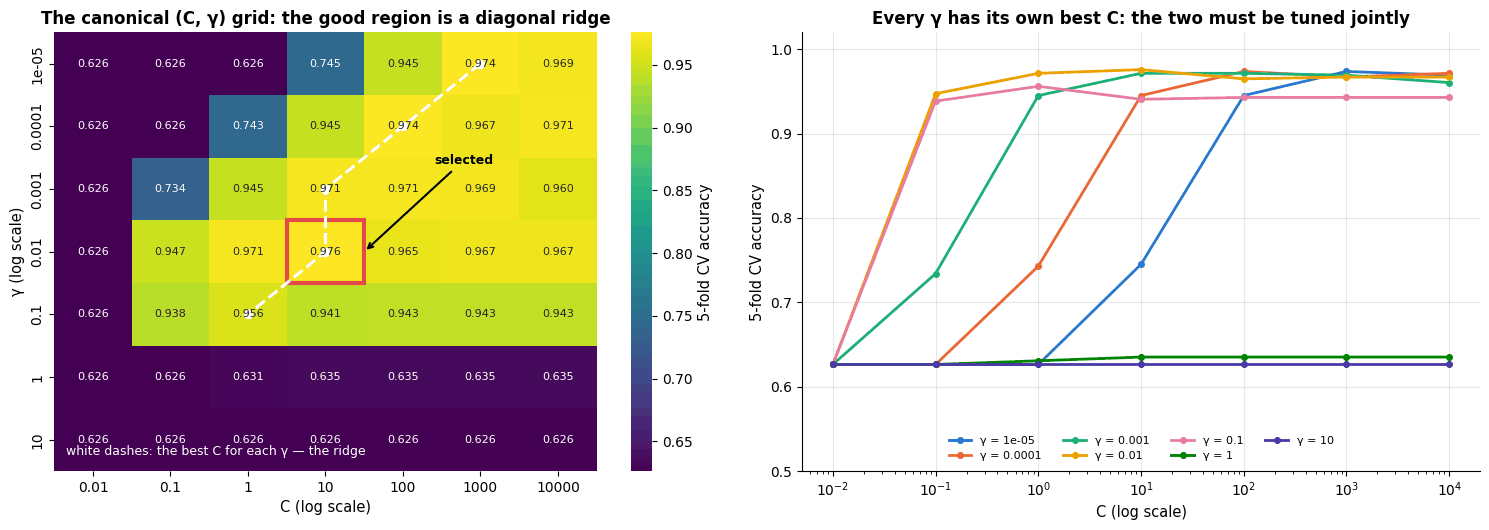

best: {'svc__C': np.float64(10.0), 'svc__gamma': np.float64(0.01)}, CV accuracy 0.9758
product C·γ along the ridge: ['0.01', '0.01', '0.01', '0.1', '0.1']


In [24]:
C_grid, gamma_grid = np.logspace(-2, 4, 7), np.logspace(-5, 1, 7)
grid_cancer = GridSearchCV(make_pipeline(StandardScaler(), SVC()),
                           {"svc__C": C_grid, "svc__gamma": gamma_grid}, cv=cv).fit(X_c_train, y_c_train)
heat = (pd.DataFrame(grid_cancer.cv_results_)
        .pivot(index="param_svc__gamma", columns="param_svc__C", values="mean_test_score").astype(float))

fig, axes = plt.subplots(1, 2, figsize=(15, 5.4))
sns.heatmap(heat, annot=True, fmt=".3f", cmap="viridis", ax=axes[0], annot_kws={"fontsize": 8},
            cbar_kws={"label": "5-fold CV accuracy"},
            xticklabels=[f"{c:g}" for c in C_grid], yticklabels=[f"{g:g}" for g in gamma_grid])
usable = heat.values.max(axis=1) > 0.80                      # rows where some C is better than chance
ridge = np.argmax(heat.values, axis=1)
axes[0].plot(ridge[usable] + 0.5, np.flatnonzero(usable) + 0.5, color="white", lw=2.2, ls="--", marker="o", ms=6)
axes[0].text(0.15, 6.75, "white dashes: the best C for each γ — the ridge", color="white", fontsize=9)
best_cell = np.unravel_index(np.argmax(heat.values), heat.shape)
axes[0].add_patch(plt.Rectangle((best_cell[1], best_cell[0]), 1, 1, fill=False, edgecolor=PALETTE[7], lw=3))
axes[0].annotate("selected", xy=(best_cell[1] + 1.0, best_cell[0] + 0.5), xytext=(best_cell[1] + 1.9, best_cell[0] - 0.9),
                 color="black", fontsize=9, fontweight="bold", arrowprops=dict(arrowstyle="->", color="black", lw=1.5))
axes[0].grid(False)
axes[0].set_xlabel("C (log scale)")
axes[0].set_ylabel("γ (log scale)")
axes[0].set_title("The canonical (C, γ) grid: the good region is a diagonal ridge")
for i, g in enumerate(gamma_grid):
    axes[1].plot(C_grid, heat.values[i], "-o", ms=4, label=f"γ = {g:g}")
axes[1].set_xscale("log"); axes[1].set_ylim(0.50, 1.02)
axes[1].set_xlabel("C (log scale)")
axes[1].set_ylabel("5-fold CV accuracy")
axes[1].set_title("Every γ has its own best C: the two must be tuned jointly")
axes[1].legend(fontsize=8, ncol=4, loc="lower center")
plt.tight_layout()
plt.show()
print(f"best: {grid_cancer.best_params_}, CV accuracy {grid_cancer.best_score_:.4f}")
print("product C·γ along the ridge:", [f"{C_grid[j] * gamma_grid[i]:.3g}" for i, j in enumerate(ridge) if usable[i]])

Three things to read off it.

- **The ridge is diagonal.** Moving down one row (ten times larger $\gamma$, a kernel ten
  times narrower) is compensated by moving one column to the left (ten times smaller $C$, a
  ten times weaker fit). Along the good cells the product $C\gamma$ stays within about one
  decade, which is why a search along a diagonal band is efficient and why tuning one
  parameter with the other fixed at a bad value tells you nothing.
- **The plateau is wide and the summit is flat.** Several cells are within a standard error
  of the best (0.976 against 0.974, 0.971 …), so any of them is a defensible choice; the
  1-SE rule says take the one with the smallest $\gamma$.
- **Failure is not symmetric.** The upper-left triangle (small $\gamma$, small $C$) degrades
  gently to the majority-class baseline of 0.626; the bottom rows (large $\gamma$) are
  *irrecoverable* — no value of $C$ rescues $\gamma \ge 1$. Spend the budget above the ridge
  rather than below it.

### 7.3 The kernel choice

`kernel` is the one categorical decision, and it should be made by cross-validation on a
couple of candidates rather than by taste. Two-dimensional data make the differences
visible; the table then repeats the comparison on the 30-dimensional breast-cancer data.

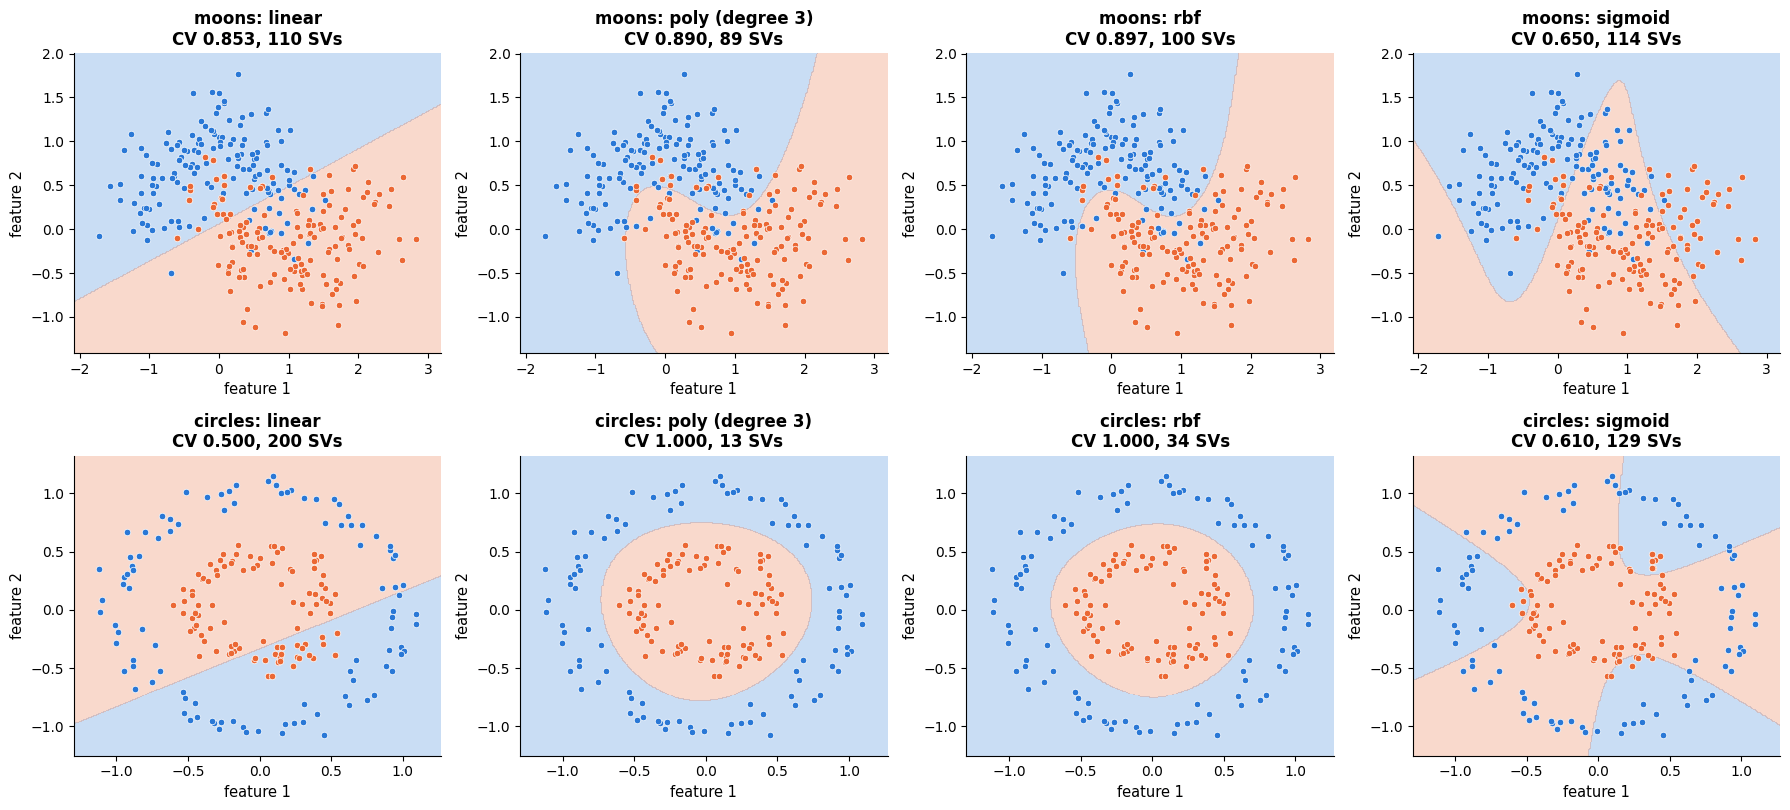

,"breast cancer, 5-fold CV accuracy"
kernel,
linear,0.9648
poly (degree 3),0.9736
rbf,0.9692
sigmoid,0.9670


In [25]:
kernels = [("linear", dict(kernel="linear")), ("poly (degree 3)", dict(kernel="poly", degree=3, coef0=1)),
           ("rbf", dict(kernel="rbf")), ("sigmoid", dict(kernel="sigmoid"))]

fig, axes = plt.subplots(2, 4, figsize=(18, 8.2))
for j, (name, kwargs) in enumerate(kernels):
    for i, (X_k, y_k, data_name) in enumerate([(X_moon, y_moon, "moons"), (X_circ, y_circ, "circles")]):
        model = SVC(C=1, **kwargs).fit(X_k, y_k)
        plot_decision_boundary(model, X_k, y_k, ax=axes[i, j], legend=False,
                               title=f"{data_name}: {name}\nCV {cross_val_score(SVC(C=1, **kwargs), X_k, y_k, cv=cv).mean():.3f}, "
                                     f"{model.n_support_.sum()} SVs")
plt.tight_layout()
plt.show()

kernel_rows = [{"kernel": name,
                "breast cancer, 5-fold CV accuracy":
                    cross_val_score(make_pipeline(StandardScaler(), SVC(C=1, **kwargs)), X_c_train, y_c_train, cv=cv).mean()}
               for name, kwargs in kernels]
pd.DataFrame(kernel_rows).set_index("kernel").round(4)

The circles row is the clean demonstration: a linear kernel scores 0.500 — it cannot do
better than a coin toss on concentric rings — while the polynomial and RBF kernels reach
1.000. The sigmoid kernel is poor on both datasets, and its boundary is visibly erratic;
it is not positive semi-definite for all parameter values, so it is not a Mercer kernel,
and it survives in the libraries for historical reasons rather than practical ones. On the
30-dimensional breast-cancer data all four are within a point of each other, which is the
usual situation in high dimensions: **when $d$ is large, data are nearly linearly separable
anyway and the kernel matters much less than the scaling and `C`**. Start with `"rbf"`; try
`"linear"` when $d \gtrsim n$ or when you need the speed of `LinearSVC`.

### 7.4 `degree` and `coef0` for the polynomial kernel

The polynomial kernel $k(\mathbf{x},\mathbf{z}) = (\gamma\,\mathbf{x}^\top\mathbf{z} + r)^p$
has two extra knobs, and beginners usually tune the wrong one. Expanding the binomial shows
why: the term of order $j$ carries the factor $\binom{p}{j} r^{\,p-j}$, so $r$ (`coef0`)
sets the relative weight of low-order against high-order interactions. With $r = 0$ *only*
the pure degree-$p$ monomials survive, and the kernel is usually a poor model.

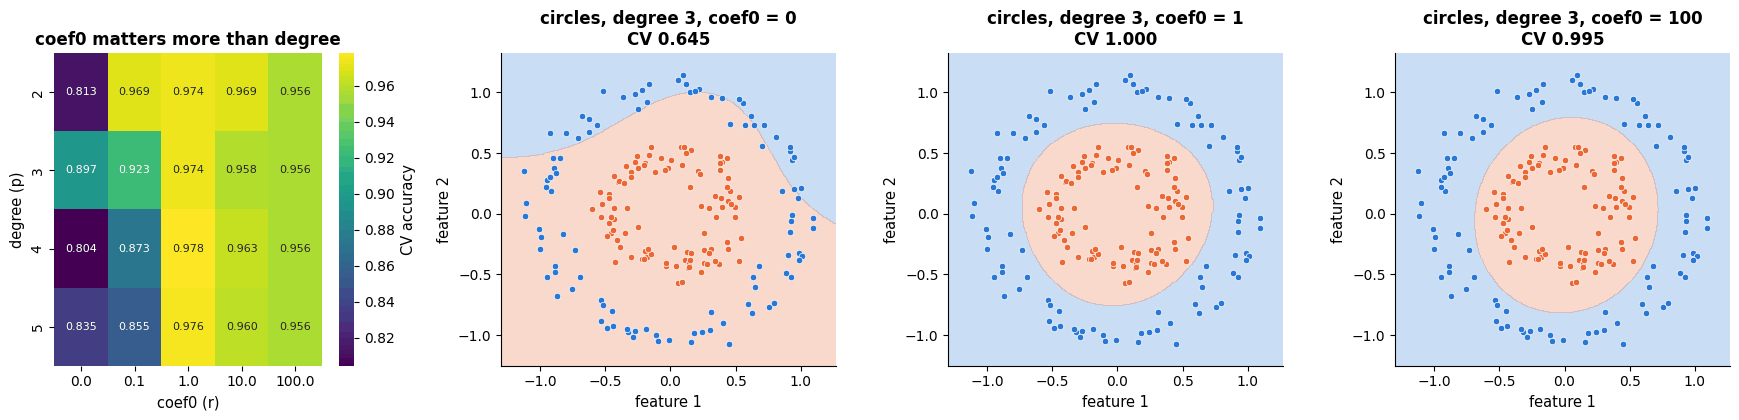

best polynomial configuration: {'svc__coef0': 1.0, 'svc__degree': 4}, CV accuracy 0.9780


In [26]:
degrees, coef0s = [2, 3, 4, 5], [0.0, 0.1, 1.0, 10.0, 100.0]
grid_poly = GridSearchCV(make_pipeline(StandardScaler(), SVC(kernel="poly", C=1)),
                         {"svc__degree": degrees, "svc__coef0": coef0s}, cv=cv).fit(X_c_train, y_c_train)
heat_poly = (pd.DataFrame(grid_poly.cv_results_)
             .pivot(index="param_svc__degree", columns="param_svc__coef0", values="mean_test_score").astype(float))

fig, axes = plt.subplots(1, 4, figsize=(17.5, 4.3))
sns.heatmap(heat_poly, annot=True, fmt=".3f", cmap="viridis", ax=axes[0], annot_kws={"fontsize": 8},
            cbar_kws={"label": "CV accuracy"})
axes[0].grid(False)
axes[0].set_xlabel("coef0 (r)")
axes[0].set_ylabel("degree (p)")
axes[0].set_title("coef0 matters more than degree")
for ax, r in zip(axes[1:], [0.0, 1.0, 100.0]):
    model = SVC(kernel="poly", degree=3, coef0=r, C=1, gamma=1).fit(X_circ, y_circ)
    plot_decision_boundary(model, X_circ, y_circ, ax=ax, legend=False,
                           title=f"circles, degree 3, coef0 = {r:g}\nCV "
                                 f"{cross_val_score(SVC(kernel='poly', degree=3, coef0=r, C=1, gamma=1), X_circ, y_circ, cv=cv).mean():.3f}")
plt.tight_layout()
plt.show()
print(f"best polynomial configuration: {grid_poly.best_params_}, CV accuracy {grid_poly.best_score_:.4f}")

Read the heat map by columns, not rows: moving from `coef0=0` to `coef0=1` gains up to
17 accuracy points, while moving from degree 2 to degree 5 at a sensible `coef0` changes
almost nothing. The boundary panels show the mechanism. With $r = 0$ only the pure cubic terms survive, so
the kernel $(\gamma\,\mathbf{x}^\top\mathbf{z})^3$ is an *odd* function of the dot product
and cannot express a closed region: the best it manages is a sweeping curve that leaves most
of the outer ring on the wrong side (CV 0.645). With $r = 1$ the constant, linear and
quadratic terms come back and the circle is recovered exactly (CV 1.000). The best cell here is degree 4, but it beats degree 2 by four thousandths of accuracy —
noise, by the standards of section 7.1. Practical rule:
**fix `degree` at 2 or 3, search `coef0` on a log-ish grid $\{0.1, 1, 10, 100\}$ jointly
with `C`**, and remember that high degrees make the kernel matrix badly conditioned and the
solver slow.

### 7.5 `epsilon` (and `C`) for SVR

For regression, $\varepsilon$ is a third dimension, and it has a physical meaning: it is the
error you are willing to ignore, in the units of $y$. We reuse the noisy sine of section 5
(noise $\sigma = 0.25$).

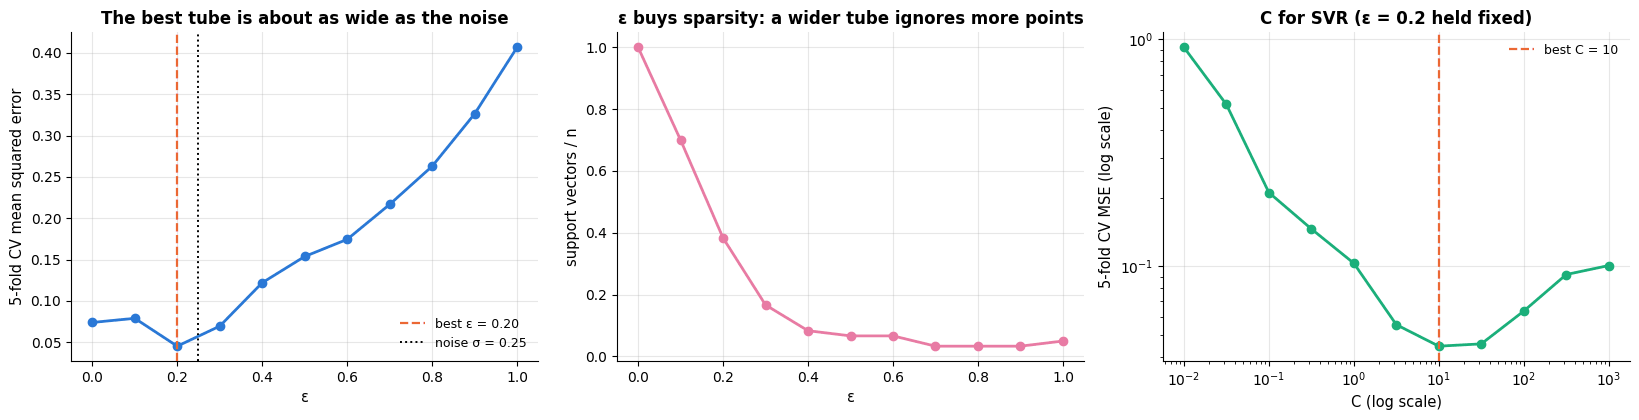

In [27]:
eps_grid, C_grid_svr = np.linspace(0, 1.0, 11), np.logspace(-2, 3, 11)
mse_eps = [-cross_val_score(SVR(kernel="rbf", C=5, gamma=5, epsilon=e), x_r[:, None], y_r, cv=5,
                            scoring="neg_mean_squared_error").mean() for e in eps_grid]
nsv_eps = [SVR(kernel="rbf", C=5, gamma=5, epsilon=e).fit(x_r[:, None], y_r).support_.size for e in eps_grid]
mse_C = [-cross_val_score(SVR(kernel="rbf", C=c, gamma=5, epsilon=0.2), x_r[:, None], y_r, cv=5,
                          scoring="neg_mean_squared_error").mean() for c in C_grid_svr]

fig, axes = plt.subplots(1, 3, figsize=(16.5, 4.3))
axes[0].plot(eps_grid, mse_eps, "-o", color=PALETTE[0])
axes[0].axvline(eps_grid[int(np.argmin(mse_eps))], color=PALETTE[1], ls="--", lw=1.6,
                label=f"best ε = {eps_grid[int(np.argmin(mse_eps))]:.2f}")
axes[0].axvline(0.25, color="black", ls=":", lw=1.4, label="noise σ = 0.25")
axes[0].set_xlabel("ε")
axes[0].set_ylabel("5-fold CV mean squared error")
axes[0].set_title("The best tube is about as wide as the noise")
axes[0].legend(fontsize=9)
axes[1].plot(eps_grid, np.array(nsv_eps) / len(x_r), "-o", color=PALETTE[4])
axes[1].set_xlabel("ε")
axes[1].set_ylabel("support vectors / n")
axes[1].set_title("ε buys sparsity: a wider tube ignores more points")
axes[2].plot(C_grid_svr, mse_C, "-o", color=PALETTE[2])
axes[2].axvline(C_grid_svr[int(np.argmin(mse_C))], color=PALETTE[1], ls="--", lw=1.6,
                label=f"best C = {C_grid_svr[int(np.argmin(mse_C))]:.3g}")
axes[2].set_xscale("log"); axes[2].set_yscale("log")
axes[2].set_xlabel("C (log scale)")
axes[2].set_ylabel("5-fold CV MSE (log scale)")
axes[2].set_title("C for SVR (ε = 0.2 held fixed)")
axes[2].legend(fontsize=9)
plt.tight_layout()
plt.show()

The CV error is minimised at $\varepsilon \approx 0.2$, essentially the noise standard
deviation — the useful rule of thumb (Smola & Schölkopf, 2004, discuss the theory): **a tube
narrower than the noise fits the noise, a tube much wider than it throws away signal**. The
middle panel shows what you buy on the way: at $\varepsilon = 0$ all 60 points are support
vectors (SVR degenerates towards a dense kernel ridge fit), at $\varepsilon = 0.3$ only ten
are, and prediction is six times cheaper. The `C` curve has the same plateau shape as in
classification, on a log scale, with a broad optimum around $C \approx 10$. Because
$\varepsilon$ is in units of $y$, always scale the target as well (e.g. with
`TransformedTargetRegressor`) or set $\varepsilon$ relative to $\operatorname{sd}(y)$.

### 7.6 `class_weight` for imbalanced classes

`class_weight="balanced"` multiplies $C$ for class $k$ by $n / (K n_k)$, so that violating
the margin on a rare positive costs more than on a common negative. It moves the boundary;
it does not add capacity. Tune it after `C` and `gamma`, and judge it with recall/precision,
never with accuracy.

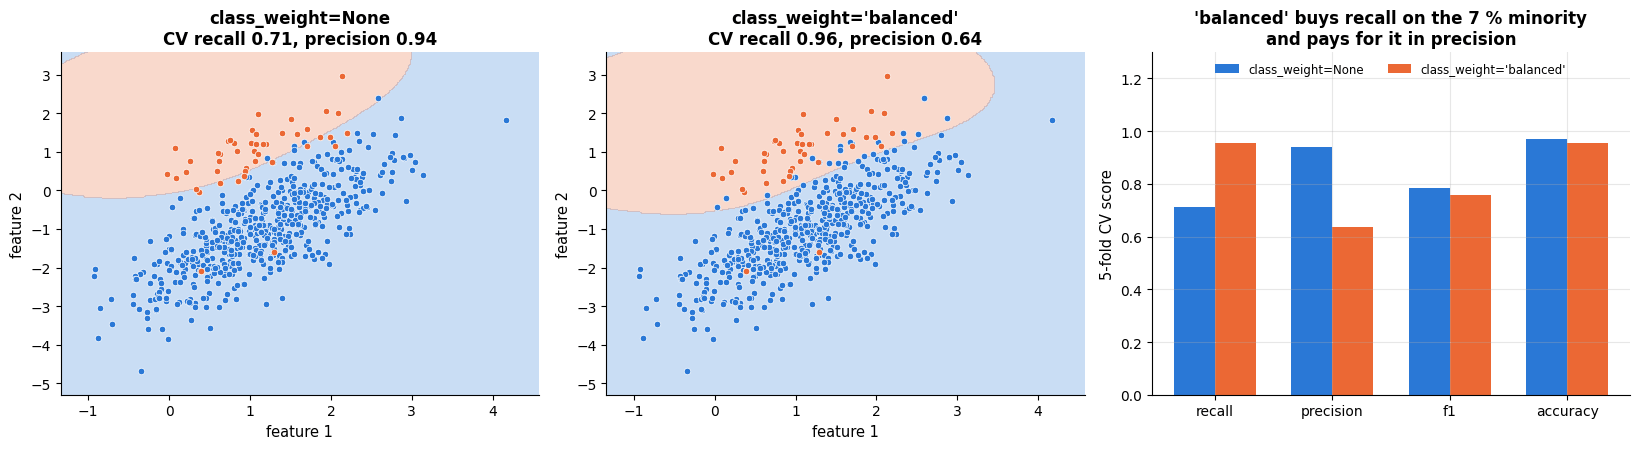

In [28]:
X_imb, y_imb = make_classification(n_samples=600, n_features=2, n_informative=2, n_redundant=0,
                                   n_clusters_per_class=1, weights=[0.93, 0.07], class_sep=1.1,
                                   flip_y=0.02, random_state=RANDOM_STATE)

fig, axes = plt.subplots(1, 3, figsize=(16.5, 4.6))
imb_scores = {}
for ax, (label, weight) in zip(axes, [("class_weight=None", None), ("class_weight='balanced'", "balanced")]):
    model = SVC(kernel="rbf", C=1, class_weight=weight)
    imb_scores[label] = {m: cross_val_score(model, X_imb, y_imb, cv=cv, scoring=m).mean()
                         for m in ["recall", "precision", "f1", "accuracy"]}
    plot_decision_boundary(model.fit(X_imb, y_imb), X_imb, y_imb, ax=ax, legend=False,
                           title=f"{label}\nCV recall {imb_scores[label]['recall']:.2f}, "
                                 f"precision {imb_scores[label]['precision']:.2f}")
metrics = ["recall", "precision", "f1", "accuracy"]
for k, (label, values) in enumerate(imb_scores.items()):
    axes[2].bar(np.arange(len(metrics)) + (k - 0.5) * 0.35, [values[m] for m in metrics], 0.35,
                label=label, color=PALETTE[k])
axes[2].set_xticks(range(len(metrics)))
axes[2].set_xticklabels(metrics)
axes[2].set_ylim(0, 1.3)
axes[2].set_ylabel("5-fold CV score")
axes[2].set_title("'balanced' buys recall on the 7 % minority\nand pays for it in precision")
axes[2].legend(fontsize=8.5, loc="upper center", ncol=2)
plt.tight_layout()
plt.show()

Recall on the minority class rises from 0.71 to 0.96 while precision falls from 0.94 to
0.64; $F_1$ barely moves and accuracy *drops* slightly. Which of the two models is better is
not a statistical question but a cost question (notebook 7, §6.5): if a missed positive
costs far more than a false alarm, `"balanced"` wins by a wide margin. The same effect can
be obtained by moving the decision threshold on `decision_function`, which is cheaper
because it does not require refitting — tune whichever you will actually deploy.

### 7.7 Practical notes

- **Always search on a log grid.** `C` and `gamma` act multiplicatively; a linear grid
  wastes almost all its points. The standard starting ranges after standardisation are
  `C` $\in 10^{-2}\ldots10^{3}$ and `gamma` $\in 10^{-4}\ldots10^{1}$ in steps of one
  decade (Hsu, Chang & Lin, 2003), then a finer grid of half-decades around the winner —
  the coarse-to-fine strategy of section 8.3.
- **If the optimum sits on the edge of the grid, the grid is wrong.** Extend it by two
  decades in that direction and search again; do not accept the edge value. An optimum at
  the largest `C` usually means the data are nearly separable and `C` has stopped mattering
  (check the plateau before extending); an optimum at the smallest `gamma` means the problem
  is essentially linear, and `LinearSVC` will be faster and just as accurate.
- **If the curve is flat, apply the one-standard-error rule** and take the smaller `C` and
  the smaller `gamma` — the smoother model, with fewer support vectors, which is also faster
  to serve.
- **Runtime cost.** `gamma` and `C` both change the number of support vectors and therefore
  the fit time; large `C` with large `gamma` is the slowest corner of the grid *and* the
  worst, so a coarse pass often saves more time than `n_jobs` does. `probability=True`
  multiplies the cost by about five — switch it on once, at the end, not during the search.
- **Not worth tuning:** `tol`, `shrinking`, `cache_size` (raise it if you have the RAM: it
  only affects speed), and `degree` beyond 2–3. `max_iter` should stay at $-1$ unless a fit
  hangs.
- **Budget.** A $7 \times 7$ grid with 5-fold CV is 245 fits — seconds on a few hundred
  samples, hours at $n = 10^5$. Subsample for the search, then refit the winner on
  everything; or use the random and Bayesian strategies of notebook 12, which reach the same
  ridge with a fraction of the evaluations.

## 8. Case study: breast cancer diagnosis with a tuned SVM

### 8.1 The data and the question

The Wisconsin breast cancer dataset (Street, Wolberg & Mangasarian, 1993) is **real data**,
not a generator: 569 patients, 30 features computed from a digitised image of a fine-needle
aspirate of a breast mass — the mean, standard error and worst value of ten cell-nucleus
measurements (radius, texture, perimeter, area, smoothness, compactness, concavity, concave
points, symmetry, fractal dimension). The label is the biopsy outcome: 212 malignant, 357
benign. The question a clinician asks of such a model is *"can this image triage which
masses need an immediate biopsy?"*, so **a false negative (calling a malignant mass benign)
is far more costly than a false positive**, and we will look at the two error types
separately rather than at accuracy alone.

The data suit an SVM almost perfectly: $n = 569$ is well below the wall of section 6.4, all
30 features are continuous measurements of the same objects, and there are no missing
values. We follow the protocol of notebook 5: the test set — 20 % of the patients,
stratified — was split off in section 2.3 and has not been touched since.

### 8.2 Baselines before tuning

Never start from the tuned model. Three baselines say how much of the work is already done
by the data: the majority class, a linear SVM with the default $C$, and an untuned RBF-SVM
inside a scaling pipeline.

In [29]:
pipe_linear = make_pipeline(StandardScaler(), LinearSVC(C=1, max_iter=20_000))
pipe_rbf_default = make_pipeline(StandardScaler(), SVC())

print(f"{'baseline':34s} {'5-fold CV accuracy':>20s}")
print(f"{'majority class (all benign)':34s} {max(np.mean(y_c_train == 1), np.mean(y_c_train == -1)):20.4f}")
for name, model in [("linear SVM, C = 1", pipe_linear), ("RBF-SVM, all defaults", pipe_rbf_default)]:
    s = cross_val_score(model, X_c_train, y_c_train, cv=cv)
    print(f"{name:34s} {s.mean():14.4f} ± {s.std(ddof=1) / np.sqrt(len(s)):.4f}")

baseline                             5-fold CV accuracy
majority class (all benign)                      0.6264
linear SVM, C = 1                          0.9604 ± 0.0075
RBF-SVM, all defaults                      0.9692 ± 0.0073


Both SVMs are already in the high nineties — on this dataset the hard work was done by
whoever designed the 30 features. Tuning will be a matter of a percentage point or two, and
the honest framing of the rest of the section is that we are looking for *small* gains and
must therefore be careful about noise.

### 8.3 Coarse to fine, with the guide of section 7

Section 7 prescribes: scale inside the pipeline, search `C` and `gamma` jointly on a coarse
log grid spanning several decades, then refine by one decade in each direction around the
winner. Two cheap $7 \times 7$ grids cost 98 configurations; a single grid of the same
resolution over the whole range would cost thousands.

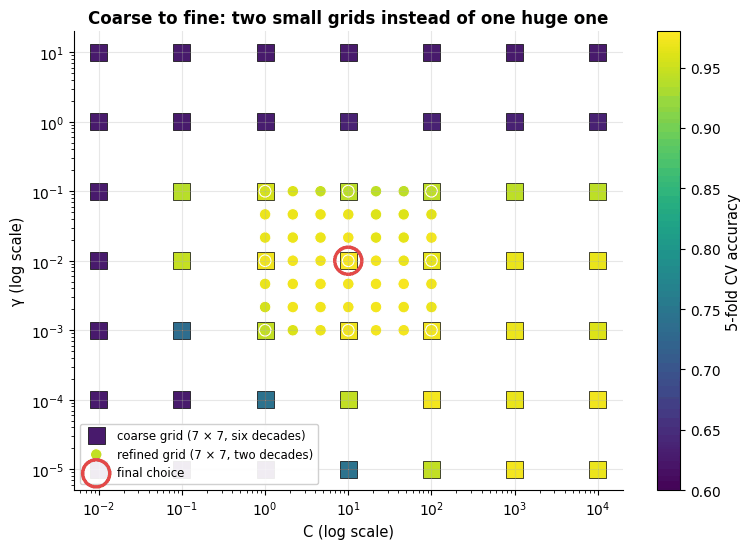

coarse: {'svc__C': np.float64(10.0), 'svc__gamma': np.float64(0.01)}  CV accuracy 0.9758
fine:   {'svc__C': np.float64(10.0), 'svc__gamma': np.float64(0.01)}  CV accuracy 0.9758


In [30]:
coarse_C, coarse_gamma = np.logspace(-2, 4, 7), np.logspace(-5, 1, 7)
search_coarse = GridSearchCV(make_pipeline(StandardScaler(), SVC()),
                             {"svc__C": coarse_C, "svc__gamma": coarse_gamma}, cv=cv).fit(X_c_train, y_c_train)
best_C, best_gamma = search_coarse.best_params_["svc__C"], search_coarse.best_params_["svc__gamma"]

fine_C = np.logspace(np.log10(best_C) - 1, np.log10(best_C) + 1, 7)          # one decade either side
fine_gamma = np.logspace(np.log10(best_gamma) - 1, np.log10(best_gamma) + 1, 7)
search_fine = GridSearchCV(make_pipeline(StandardScaler(), SVC()),
                           {"svc__C": fine_C, "svc__gamma": fine_gamma}, cv=cv).fit(X_c_train, y_c_train)

res_coarse, res_fine = pd.DataFrame(search_coarse.cv_results_), pd.DataFrame(search_fine.cv_results_)
fig, ax = plt.subplots(figsize=(7.8, 5.6))
points = ax.scatter(res_coarse["param_svc__C"].astype(float), res_coarse["param_svc__gamma"].astype(float),
                    c=res_coarse["mean_test_score"], cmap="viridis", s=150, marker="s", edgecolor="black",
                    lw=0.5, vmin=0.60, vmax=0.98, label="coarse grid (7 × 7, six decades)")
ax.scatter(res_fine["param_svc__C"].astype(float), res_fine["param_svc__gamma"].astype(float),
           c=res_fine["mean_test_score"], cmap="viridis", s=70, marker="o", edgecolor="white",
           lw=0.8, vmin=0.60, vmax=0.98, label="refined grid (7 × 7, two decades)")
ax.scatter([search_fine.best_params_["svc__C"]], [search_fine.best_params_["svc__gamma"]], s=380,
           facecolors="none", edgecolors=PALETTE[7], lw=2.5, label="final choice")
plt.colorbar(points, ax=ax, label="5-fold CV accuracy")
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("C (log scale)")
ax.set_ylabel("γ (log scale)")
ax.set_title("Coarse to fine: two small grids instead of one huge one")
ax.legend(loc="lower left", fontsize=8.5, frameon=True, framealpha=0.92, facecolor="white")
plt.tight_layout()
plt.show()
print(f"coarse: {search_coarse.best_params_}  CV accuracy {search_coarse.best_score_:.4f}")
print(f"fine:   {search_fine.best_params_}  CV accuracy {search_fine.best_score_:.4f}")

The refinement finds the same configuration and the same score as the coarse grid — which is
the expected outcome on a flat summit (section 7.2) and exactly the moment to **stop
tuning**. A refinement that does not improve the CV score is not a failed experiment; it is
evidence that the plateau is real and that further search would be fitting the folds rather
than the problem (notebook 12, §6.1 quantifies how badly that can mislead). Note also that
the winner sits comfortably inside the coarse grid rather than on its edge, so the ranges of
section 7.7 did not need extending.

### 8.4 How the tuned SVM compares with other model families

The same protocol on two real datasets — breast cancer and the 8 × 8 handwritten digits
(1 797 images, 64 pixels, 10 classes) — against the models of notebooks 7 and 10.

In [31]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

datasets = {
    "breast cancer": (X_c_train, X_c_test, y_c_train, y_c_test),
    "digits": (X_d_train, X_d_test, y_d_train, y_d_test),
}
svm_grid = {"svc__C": [1, 10, 100], "svc__gamma": [0.001, 0.003, 0.01, 0.03]}
results = []
for dname, (Xtr, Xte, ytr, yte) in datasets.items():
    models = {
        "logistic regression": make_pipeline(StandardScaler(), LogisticRegression(max_iter=5000)),
        "random forest (300 trees)": RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE),
        "SVM (RBF, tuned C, γ)": GridSearchCV(make_pipeline(StandardScaler(), SVC(kernel="rbf")), svm_grid, cv=cv),
    }
    for mname, model in models.items():
        t0 = time.perf_counter()
        model.fit(Xtr, ytr)
        fit_time = time.perf_counter() - t0
        cv_acc = model.best_score_ if hasattr(model, "best_score_") else cross_val_score(model, Xtr, ytr, cv=cv).mean()
        results.append({"dataset": dname, "model": mname, "CV accuracy": cv_acc, "test accuracy": model.score(Xte, yte),
                        "fit time (s)": fit_time, "chosen params": getattr(model, "best_params_", "")})
pd.DataFrame(results).set_index(["dataset", "model"]).round(3)

CV accuracy  ...                       chosen params
dataset       model                                   ...                                    
breast cancer logistic regression              0.978  ...                                    
              random forest (300 trees)        0.965  ...                                    
              SVM (RBF, tuned C, γ)            0.976  ...  {'svc__C': 10, 'svc__gamma': 0.01}
digits        logistic regression              0.966  ...                                    
              random forest (300 trees)        0.977  ...                                    
              SVM (RBF, tuned C, γ)            0.984  ...  {'svc__C': 10, 'svc__gamma': 0.01}

[6 rows x 4 columns]

On the digits the RBF-SVM is the most accurate model of the three — a well-tuned kernel
SVM on standardised pixels was, for many years, the strongest classifier on datasets of
this kind (the LIBSVM guide's recommendations of the early 2000s still work). On the
breast cancer data all three models are within a few misclassified tumours of each other,
which the standard error of a 114-sample test set cannot separate (notebook 12 discusses
how to compare models properly).

### 8.5 Honest evaluation on the untouched test set

One evaluation, once, of the tuned model and of the linear baseline, looking at the two
error types separately.

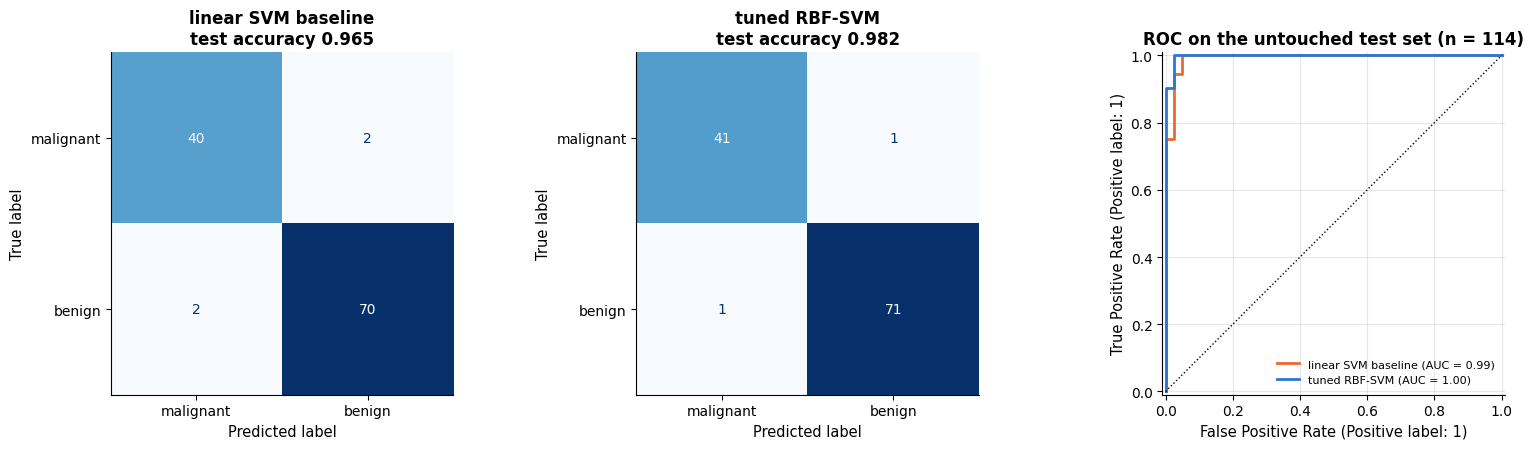

linear SVM baseline    accuracy 0.965  AUC 0.9927  sensitivity to malignant 0.952  missed malignancies 2 of 42
tuned RBF-SVM          accuracy 0.982  AUC 0.9977  sensitivity to malignant 0.976  missed malignancies 1 of 42


In [32]:
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay, confusion_matrix, recall_score, roc_auc_score

svm_final = search_fine.best_estimator_
linear_final = pipe_linear.fit(X_c_train, y_c_train)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.6))
for ax, (name, model) in zip(axes[:2], [("linear SVM baseline", linear_final), ("tuned RBF-SVM", svm_final)]):
    ConfusionMatrixDisplay(confusion_matrix(y_c_test, model.predict(X_c_test), labels=[-1, 1]),
                           display_labels=["malignant", "benign"]).plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(f"{name}\ntest accuracy {model.score(X_c_test, y_c_test):.3f}")
    ax.grid(False)
for name, model, colour in [("linear SVM baseline", linear_final, PALETTE[1]), ("tuned RBF-SVM", svm_final, PALETTE[0])]:
    RocCurveDisplay.from_estimator(model, X_c_test, y_c_test, ax=axes[2], name=name, curve_kwargs={"color": colour})
axes[2].plot([0, 1], [0, 1], "k:", lw=1)
axes[2].set_title("ROC on the untouched test set (n = 114)")
axes[2].legend(fontsize=8, loc="lower right")
plt.tight_layout()
plt.show()

for name, model in [("linear SVM baseline", linear_final), ("tuned RBF-SVM", svm_final)]:
    pred = model.predict(X_c_test)
    print(f"{name:22s} accuracy {model.score(X_c_test, y_c_test):.3f}  "
          f"AUC {roc_auc_score(y_c_test, model.decision_function(X_c_test)):.4f}  "
          f"sensitivity to malignant {recall_score(y_c_test, pred, pos_label=-1):.3f}  "
          f"missed malignancies {int(((pred == 1) & (y_c_test == -1)).sum())} of {int((y_c_test == -1).sum())}")

The tuned SVM makes one error of each kind where the linear baseline makes two — two
mistakes in total against four. On 114 patients that difference is **two patients**, far
inside the noise of a test set this size
(the standard error of an accuracy near 0.97 on 114 samples is about 0.016). The correct
report is therefore *"the two models are indistinguishable on this test set, and both agree
with their cross-validated estimates"* — not "the SVM is better". What the test set does
confirm is the absence of a nasty surprise: the tuned CV accuracy (0.976) and the test
accuracy agree, so the tuning did not silently overfit the folds.

### 8.6 When to stop using a kernel SVM

This dataset is comfortably inside the kernel SVM's home territory. The decision rule for
when it is not, from the measurements of sections 4.3 and 6.4:

| Situation | What to use instead | Why |
|---|---|---|
| $n \lesssim 10^4$, continuous features | `SVC(kernel="rbf")` in a scaling pipeline | exact solution, seconds to fit |
| $n \approx 10^4$–$10^5$ | `Nystroem(n_components=300…1000)` + `LinearSVC`/`LogisticRegression` | $O(nDd)$ instead of $O(n^2 d)$, within ~1 point of the exact accuracy |
| $n > 10^5$, or streaming | `SGDClassifier(loss="hinge")` — Pegasos, section 2.3 | one pass over the data, constant memory |
| $d \gtrsim n$, sparse (text) | `LinearSVC` | the boundary is already linear in that space; the kernel buys nothing |
| mixed types, missing values | `HistGradientBoosting*` (notebook 10) | kernels need a meaningful Euclidean distance; trees do not |
| calibrated probabilities needed | logistic regression (notebook 7), or `CalibratedClassifierCV` | an SVM's `decision_function` is not a probability |

A concrete trigger: if a single fit takes more than a few minutes, or if the kernel matrix
($8n^2$ bytes) does not fit in memory, you have hit the wall — switch to the approximation
rather than to a bigger machine, because the next doubling of $n$ costs four times as much
again.

### 8.7 What to tell a non-technical stakeholder

> We built an automatic reader for the cell-measurement data from fine-needle aspirates. On
> 114 patients that the model had never seen it agreed with the biopsy for 112 of them, and
> it missed one malignant mass. It is not a replacement for a pathologist: we recommend it
> as a triage aid that flags the cases that need attention first, with a threshold set so
> that malignant masses are almost never missed — that setting produces more false alarms,
> which cost a second look rather than a missed cancer. We cannot tell you *why* the model
> flags a particular patient beyond "these cell nuclei are large and irregular"; if an
> explanation per patient is a requirement, the logistic-regression model on the same
> features is about equally accurate and can give one (notebook 7). Before any clinical
> use the model must be re-validated on patients from your own hospital and imaging
> equipment: these 569 cases come from one institution in the early 1990s.

**When to reach for an SVM.** It is a strong candidate when $n$ is small to medium
(hundreds to tens of thousands), the features are homogeneous and continuous (pixels,
spectra, embeddings) or a natural similarity/kernel exists (strings, graphs), and a
non-linear boundary is needed but the data are too scarce for the flexible models of a
dedicated deep-learning course. Linear SVMs remain a default for high-dimensional sparse
text. Prefer other tools when $n$ is large (gradient boosting), when the features are
heterogeneous tabular columns with categoricals and missing values (tree ensembles,
notebook 10), when calibrated probabilities or interpretability matter (logistic
regression), or when training time and memory are tight.

## Summary

- The **maximum-margin** classifier chooses the separating hyperplane furthest from the
  closest points; those points are the **support vectors** and alone determine the
  solution. Hard margin: $\min \tfrac12\|\mathbf{w}\|^2$ s.t. $y_i f(\mathbf{x}_i) \ge 1$.
- The **soft-margin** SVM adds slack at price $C$; eliminating the slack shows that it is
  $L_2$-regularised **hinge-loss** minimisation with $\lambda = 1/(nC)$ — the same family as
  logistic regression, with a loss that is zero beyond the margin (hence sparsity, hence no
  probabilities). Sub-gradient descent (Pegasos) trains it in a few lines and matches LIBSVM.
- In the **dual**, data appear only through dot products, so any Mercer **kernel**
  $k(\mathbf{x}, \mathbf{z}) = \boldsymbol{\phi}(\mathbf{x})^\top\boldsymbol{\phi}(\mathbf{z})$ can replace
  them: polynomial kernels give finite, RBF kernels infinite feature spaces at $O(d)$ cost.
  $\gamma$ controls smoothness, $C$ the tolerance for violations; tune both on a log grid.
- **Practice:** scale features inside a pipeline; `class_weight` for imbalance; Platt
  scaling for probabilities; one-vs-one for multi-class; `LinearSVC`/`SGDClassifier` or
  `Nystroem`/`RBFSampler` + linear model when $n$ is large, because exact kernel SVMs cost
  $O(n^2)$–$O(n^3)$.
- The same kernel expansion yields **SVR** (ε-insensitive loss, sparse), **kernel ridge**
  (squared loss, closed form, dense) and **Gaussian-process regression** (KRR's mean plus a
  predictive variance and marginal-likelihood hyper-parameter selection).
- Three failures were **measured**, not asserted: fit time grows as $n^{2}$ (section 6.4),
  a large $\gamma$ drives training accuracy to 1 while CV accuracy collapses to near-chance
  (6.5), and raw feature units cost six accuracy points because the kernel only sees the
  largest column (6.6).
- **Tuning** is a short recipe: scale → a log grid over $C$ and $\gamma$ *jointly* (the good
  cells form a diagonal ridge on which $C\gamma$ is roughly constant) → the kernel → then
  `coef0` (which matters far more than `degree`), `class_weight`, or $\varepsilon \approx$
  the noise level for SVR. Refine coarse-to-fine, extend any range whose optimum sits on an
  edge, and prefer the smoother model when the summit is flat.

| Task | Tool / rule of thumb |
|---|---|
| Linear SVM, small/medium $n$ | `SVC(kernel="linear")` (exact dual) or `LinearSVC` (faster; squared hinge, penalised bias) |
| Linear SVM, large or sparse $n$ | `LinearSVC`, `SGDClassifier(loss="hinge")` |
| Non-linear boundary | `SVC(kernel="rbf")`, grid over `C` ∈ $10^{-2..3}$, `gamma` ∈ $10^{-3..2}$ (log scale), after `StandardScaler` |
| Kernel SVM with $n \gtrsim 10^4$–$10^5$ | `Nystroem(n_components=...)` or `RBFSampler` + `LinearSVC` / `LogisticRegression` |
| Probabilities | `SVC(probability=True)` (Platt) or `CalibratedClassifierCV`; or use logistic regression |
| Imbalanced classes | `class_weight="balanced"`, evaluate with PR-AUC / $F_1$ |
| Regression | `SVR` (robust, sparse), `KernelRidge` (closed form), `GaussianProcessRegressor` (uncertainty) |
| Cost | training $O(n^2 d)$–$O(n^3 d)$, memory $O(n^2)$, prediction $O(n_{\text{SV}} d)$ |

**Next steps:** notebook 12 (model selection) tunes $C$ and $\gamma$ systematically and
uses Gaussian processes for Bayesian optimisation; notebook 14 applies the kernel trick to
PCA; notebook 15 uses linear SVMs on TF-IDF text features; notebook 8 (kNN) is the natural comparison for the RBF-SVM's
"soft nearest-neighbour" decision function.

## Exercises

### Exercise 1 — Squared hinge (easy)
Modify `HingeLinearSVM` to minimise the *squared* hinge loss $\max(0, 1 - m)^2$ (the
`LinearSVC` default). Derive the gradient first. Compare the objective curve and the
number of margin violators with the plain hinge on the breast cancer data.

<details><summary>Solution sketch</summary>

For $m_i = y_i f(\mathbf{x}_i) < 1$ the per-sample gradient w.r.t. $\mathbf{w}$ is
$-2(1 - m_i)\,y_i\mathbf{x}_i$ (and $-2(1 - m_i)y_i$ for $b$); zero otherwise. Replace
`yb[active] @ Xb[active]` by `(2 * (1 - margin[active]) * yb[active]) @ Xb[active]`. The
squared hinge is smooth, so the objective curve is less jagged; it penalises large
violations more heavily, which makes it somewhat less robust to label noise.
</details>

### Exercise 2 — A cubic feature map (easy)
Write the explicit feature map $\boldsymbol{\phi}$ of the kernel $(\mathbf{x}^\top\mathbf{z} + 1)^3$
in two dimensions (it has $\binom{5}{3} = 10$ coordinates) and verify numerically, as in
section 3.3, that $\boldsymbol{\phi}(\mathbf{x})^\top\boldsymbol{\phi}(\mathbf{z})$ equals
`polynomial_kernel(..., degree=3, gamma=1, coef0=1)`.

<details><summary>Solution sketch</summary>

Expand with the multinomial theorem: the coordinate for the monomial $x_1^{a}x_2^{b}$ with
$a + b = k \le 3$ is $\sqrt{\binom{3}{k}\binom{k}{a}}\,x_1^a x_2^b$. So
$\boldsymbol{\phi}(\mathbf{x}) = (1, \sqrt3 x_1, \sqrt3 x_2, \sqrt3 x_1^2, \sqrt6 x_1x_2, \sqrt3 x_2^2, x_1^3, \sqrt3 x_1^2x_2, \sqrt3 x_1x_2^2, x_2^3)$.
</details>

### Exercise 3 — The $(\gamma, C)$ ridge on real data (medium)
Repeat the heat-map of section 3.4 for the standardised breast cancer training data with
`gamma` in `np.logspace(-4, 1, 6)` and `C` in `np.logspace(-2, 3, 6)`. Where is the ridge,
and how does the best `gamma` compare with the default `gamma="scale"` $= 1/(d \cdot \operatorname{Var})$
(here $1/30$ after standardisation)?

<details><summary>Solution sketch</summary>

```py
grid = GridSearchCV(make_pipeline(StandardScaler(), SVC()), {"svc__gamma": np.logspace(-4, 1, 6), "svc__C": np.logspace(-2, 3, 6)}, cv=cv)
```
The ridge runs from (small $\gamma$, large $C$) to (large $\gamma$, small $C$); the best
$\gamma$ is around $10^{-3}$–$10^{-2}$, i.e. of the same order as the default $0.033$ —
`gamma="scale"` is a sensible starting point, not a substitute for tuning.
</details>

### Exercise 4 — How many landmarks? (medium)
For the 16 000-sample problem of section 4.3, vary `n_components` of `Nystroem` in
`[50, 100, 200, 400, 800, 1600]` and plot test accuracy and training time against it.
At what $D$ does the approximation match the exact SVM, and how does the time compare?

<details><summary>Solution sketch</summary>

Accuracy rises quickly and saturates a few hundred components below the exact SVM's
accuracy (within ~1 %) while the time grows linearly in $D$ (the $D \times D$ eigendecomposition
becomes noticeable beyond ~1 000). A few hundred landmarks is the usual sweet spot.
</details>

### Exercise 5 — SVR hyper-parameters (medium)
On the sine data of section 5, run a grid search for `SVR` over `C` ∈ $\{0.1, 1, 10, 100\}$,
`gamma` ∈ $\{1, 5, 20\}$ and `epsilon` ∈ $\{0.05, 0.2, 0.5\}$ with `scoring="neg_mean_squared_error"`
and 5-fold CV. Plot the best model and its tube. Is the CV-optimal $\varepsilon$ related
to the noise level ($\sigma = 0.25$)?

<details><summary>Solution sketch</summary>

The best $\varepsilon$ is typically of the order of the noise standard deviation: a tube
much narrower than the noise fits the noise (many support vectors), a much wider one
ignores the signal. Note that with 60 points the CV estimate is noisy — repeat the search
with `RepeatedKFold` to confirm.
</details>

### Exercise 6 — Kernel PCA preview (hard)
Kernel PCA (notebook 14) applies the kernel trick to PCA: it eigendecomposes the centred
kernel matrix $\tilde{\mathbf{K}} = \mathbf{H}\mathbf{K}\mathbf{H}$ with
$\mathbf{H} = \mathbf{I} - \tfrac{1}{n}\mathbf{1}\mathbf{1}^\top$. Implement it with NumPy for the
circles data and an RBF kernel ($\gamma = 5$), project onto the top two eigenvectors and
show that a *linear* SVM separates the two rings in the projected space. Compare with
`sklearn.decomposition.KernelPCA`.

<details><summary>Solution sketch</summary>

```py
K = rbf_kernel(X_circ, gamma=5); n = len(K); H = np.eye(n) - np.ones((n, n)) / n
vals, vecs = np.linalg.eigh(H @ K @ H)
Z = vecs[:, -2:] * np.sqrt(vals[-2:])          # top two components (eigh returns ascending order)
print(cross_val_score(SVC(kernel="linear"), Z, y_circ, cv=cv).mean())
```
The first kernel principal component already separates inner from outer ring, so a
linear SVM in the 2-D projection reaches ~100 % accuracy. `KernelPCA(n_components=2, kernel="rbf", gamma=5).fit_transform(X_circ)`
gives the same coordinates up to sign.
</details>

## References and further reading

### Textbooks

- James, G., Witten, D., Hastie, T., Tibshirani, R., & Taylor, J. (2023). *An Introduction to Statistical Learning with Applications in Python*. Springer. (free at https://www.statlearning.com) — Chapter 9 covers maximal-margin classifiers, support vector classifiers and SVMs at the level of this notebook, with the ROC-based comparison to logistic regression.
- Hastie, T., Tibshirani, R., & Friedman, J. (2009). *The Elements of Statistical Learning* (2nd ed.). Springer. (free) — Chapter 12 (SVMs and flexible discriminants) gives the dual derivation, the hinge-loss view and the kernel connection; §5.8 covers kernel ridge / RKHS.
- Bishop, C. M. (2006). *Pattern Recognition and Machine Learning*. Springer. (free) — Chapter 6 (kernel methods, Gaussian processes) and chapter 7 (sparse kernel machines: SVM, SVR, relevance vector machines).
- Schölkopf, B., & Smola, A. J. (2002). *Learning with Kernels*. MIT Press. — The reference monograph on kernel methods: Mercer's theorem, kernel design, SVM/SVR optimisation.
- Rasmussen, C. E., & Williams, C. K. I. (2006). *Gaussian Processes for Machine Learning*. MIT Press. (free at http://gaussianprocess.org/gpml/) — Chapter 2 derives the regression equations of section 5.3; chapter 5 covers marginal-likelihood hyper-parameter selection; chapter 8 sparse approximations.
- Boyd, S., & Vandenberghe, L. (2004). *Convex Optimization*. Cambridge University Press. (free) — Chapter 5 on Lagrange duality and the KKT conditions behind section 3.1.
- Vapnik, V. N. (1995). *The Nature of Statistical Learning Theory*. Springer. — The theory of margins and structural risk minimisation from the inventor of the SVM; also introduces the $\varepsilon$-insensitive loss of SVR.

### Papers

- Boser, B. E., Guyon, I. M., & Vapnik, V. N. (1992). A training algorithm for optimal margin classifiers. *Proceedings of COLT 1992*, 144–152. — The kernelised maximum-margin classifier.
- Cortes, C., & Vapnik, V. (1995). Support-vector networks. *Machine Learning*, 20(3), 273–297. — The soft-margin SVM with slack variables and $C$.
- Aizerman, M. A., Braverman, E. M., & Rozonoer, L. I. (1964). Theoretical foundations of the potential function method in pattern recognition learning. *Automation and Remote Control*, 25, 821–837. — The origin of the kernel trick.
- Shalev-Shwartz, S., Singer, Y., Srebro, N., & Cotter, A. (2011). Pegasos: primal estimated sub-gradient solver for SVM. *Mathematical Programming*, 127(1), 3–30. — The algorithm of section 2.3, with its $\tilde{O}(1/(\lambda\epsilon))$ convergence guarantee.
- Platt, J. C. (1998). Sequential minimal optimization: a fast algorithm for training support vector machines. Microsoft Research Technical Report MSR-TR-98-14. — The dual solver inside LIBSVM.
- Platt, J. C. (1999). Probabilistic outputs for support vector machines and comparisons to regularized likelihood methods. In *Advances in Large Margin Classifiers*, MIT Press, 61–74. — Platt scaling (`probability=True`).
- Chang, C.-C., & Lin, C.-J. (2011). LIBSVM: a library for support vector machines. *ACM Transactions on Intelligent Systems and Technology*, 2(3), 1–27. — The library behind `SVC`/`SVR`; the paper documents the exact optimisation problems solved.
- Fan, R.-E., Chang, K.-W., Hsieh, C.-J., Wang, X.-R., & Lin, C.-J. (2008). LIBLINEAR: a library for large linear classification. *Journal of Machine Learning Research*, 9, 1871–1874. — The solver behind `LinearSVC`, including the penalised-bias detail of section 2.4.
- Hsu, C.-W., Chang, C.-C., & Lin, C.-J. (2003). *A practical guide to support vector classification*. Technical report, National Taiwan University. (free) — Scale, use RBF, grid-search $C$ and $\gamma$ on a log scale: still the best ten-page recipe.
- Rahimi, A., & Recht, B. (2007). Random features for large-scale kernel machines. *Advances in NIPS 20*. — Random Fourier features (`RBFSampler`).
- Williams, C. K. I., & Seeger, M. (2001). Using the Nyström method to speed up kernel machines. *Advances in NIPS 13*. — The Nyström approximation (`Nystroem`).
- Smola, A. J., & Schölkopf, B. (2004). A tutorial on support vector regression. *Statistics and Computing*, 14(3), 199–222. — A readable derivation of the ε-insensitive loss and its dual, including the rule of thumb for $\varepsilon$ used in section 7.5.
- Street, W. N., Wolberg, W. H., & Mangasarian, O. L. (1993). Nuclear feature extraction for breast tumor diagnosis. *Proceedings of SPIE 1905*, 861–870. — The source of the breast cancer Wisconsin data used throughout and in the case study of section 8.

### Documentation and online resources

- scikit-learn user guide, *Support Vector Machines* — https://scikit-learn.org/stable/modules/svm.html — parameters, complexity, the exact objectives of `SVC` and `LinearSVC`, tips on practical use.
- scikit-learn user guide, *Kernel Approximation* — https://scikit-learn.org/stable/modules/kernel_approximation.html — `Nystroem`, `RBFSampler` and friends.
- scikit-learn user guide, *Gaussian Processes* — https://scikit-learn.org/stable/modules/gaussian_process.html — kernels, `GaussianProcessRegressor` and `GaussianProcessClassifier`.
- scikit-learn user guide, *Kernel ridge regression* — https://scikit-learn.org/stable/modules/kernel_ridge.html — including a timing comparison with SVR.